# 02b - Secondary Analysis

Chat comparisons, correlations, within-participant patterns, and dilemma type analysis.

In [1]:
source("00_setup.R")

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘jsonlite’ was built under R version 4.3.3”

Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten


Loading pre-processed data...

Loaded: 24 participants, 192 observations, 96 chat observations


=== Data Loaded ===

Participants: 24

Total observations (data_long): 192

Chat observations (data_chat_analysis): 96



## Chat vs Non-Chat Comparison


=== CHAT VS NON-CHAT: LIKELIHOOD AND MAGNITUDE OF CHANGE ===

Summary:



# A tibble: 2 × 8
  dilemma_type     n n_changed pct_changed mean_change median_change sd_change
  <fct>        <int>     <int>       <dbl>       <dbl>         <dbl>     <dbl>
1 Non-chat        96        42        43.8       0.719             0      1.03
2 Chat            96        44        45.8       1.05              0      1.46
# ℹ 1 more variable: se_change <dbl>



--- Likelihood of Change ---

Chat: 45.8% changed | Non-chat: 43.8% changed

Proportion test: Chi-squared=0.02, p=0.8846 


--- Magnitude of Change ---

Chat vs Non-chat: mean=1.05 vs 0.72, W=4953, p=0.3229 


--- Paired Analysis (within-participant) ---

Participants with both types: 24


Likelihood: Chat=45.8% vs Non-chat=43.8%, V=116, p=0.6652 

Magnitude: Chat=1.05 vs Non-chat=0.72, V=220, p=0.0472 *



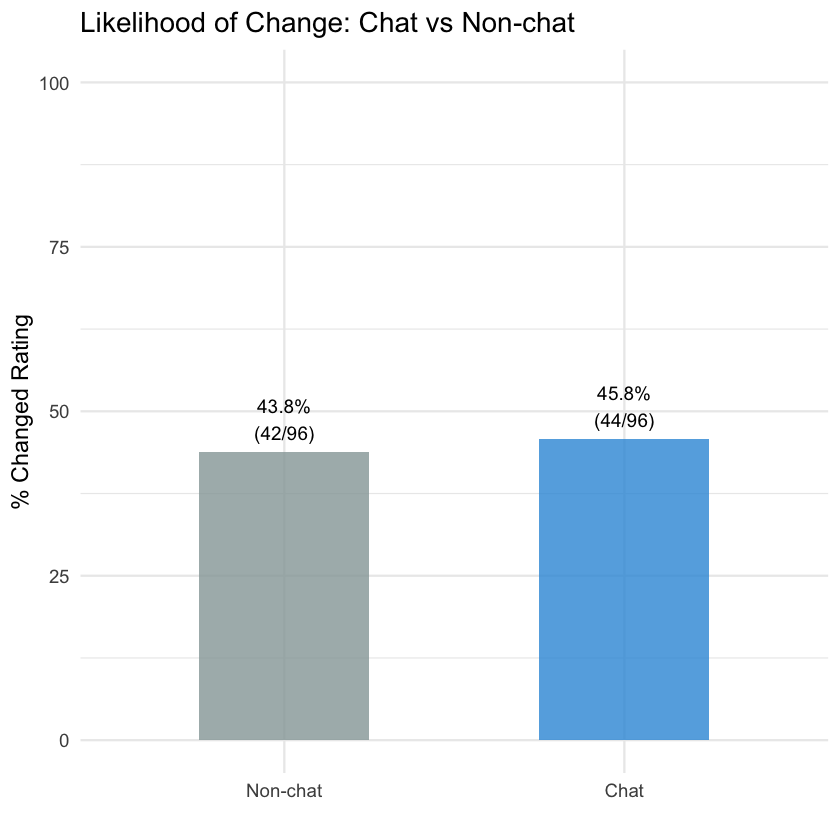

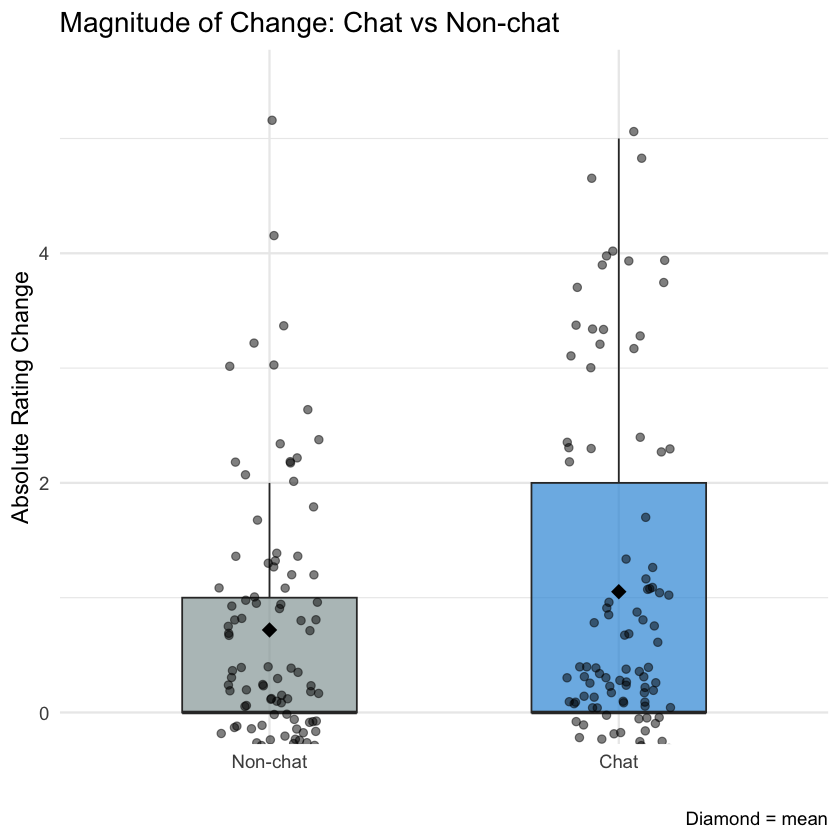

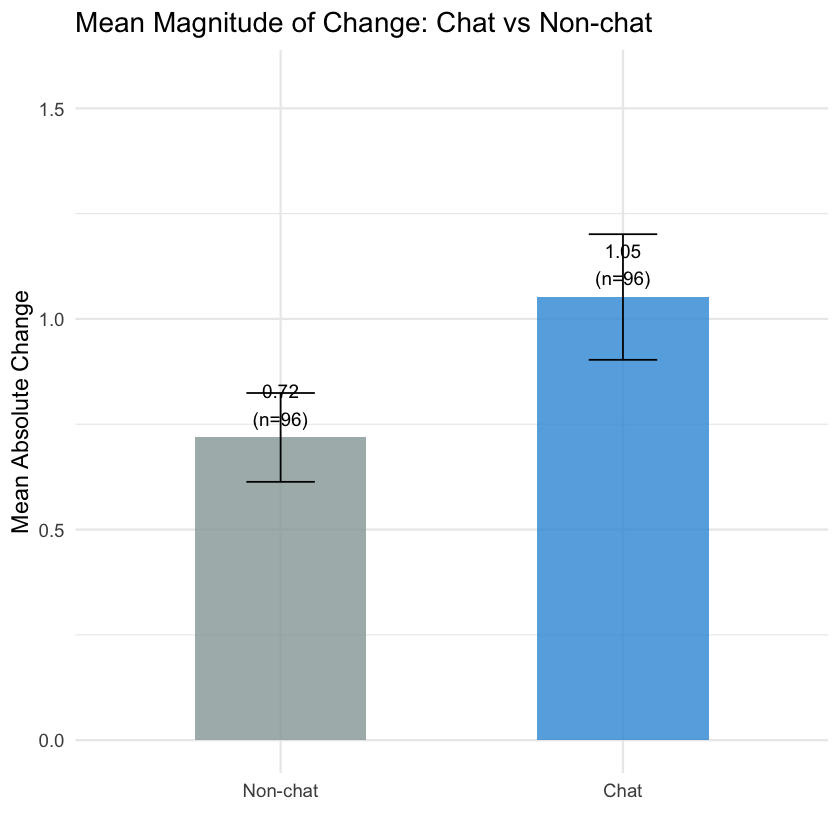

In [2]:
message("\n=== CHAT VS NON-CHAT: LIKELIHOOD AND MAGNITUDE OF CHANGE ===")

chat_change_data <- data_long %>%
mutate(
dilemma_type = ifelse(had_chat, "Chat", "Non-chat"),
dilemma_type = factor(dilemma_type, levels = c("Non-chat", "Chat")),
changed = rating_change != 0,
abs_change = abs(rating_change)
)

# Summary stats
chat_stats <- chat_change_data %>%
group_by(dilemma_type) %>%
summarise(
n = n(),
n_changed = sum(changed),
pct_changed = round(n_changed / n * 100, 1),
mean_change = mean(abs_change),
median_change = median(abs_change),
sd_change = sd(abs_change),
se_change = sd_change / sqrt(n),
.groups = "drop"
)

message("Summary:")
print(chat_stats)

# --- Likelihood of Change ---
message("\n--- Likelihood of Change ---")

# Proportion test
chat_n <- chat_stats$n[chat_stats$dilemma_type == "Chat"]
chat_changed <- chat_stats$n_changed[chat_stats$dilemma_type == "Chat"]
nonchat_n <- chat_stats$n[chat_stats$dilemma_type == "Non-chat"]
nonchat_changed <- chat_stats$n_changed[chat_stats$dilemma_type == "Non-chat"]

prop_res <- prop.test(c(chat_changed, nonchat_changed), c(chat_n, nonchat_n))
message(sprintf("Chat: %.1f%% changed | Non-chat: %.1f%% changed",
          chat_changed/chat_n*100, nonchat_changed/nonchat_n*100))
message(sprintf("Proportion test: Chi-squared=%.2f, p=%.4f %s",
          prop_res$statistic, prop_res$p.value,
          ifelse(prop_res$p.value < 0.05, "*", "")))

# --- Magnitude of Change ---
message("\n--- Magnitude of Change ---")

chat_magnitude <- chat_change_data %>% filter(dilemma_type == "Chat") %>% pull(abs_change)
nonchat_magnitude <- chat_change_data %>% filter(dilemma_type == "Non-chat") %>% pull(abs_change)

wilcox_res <- wilcox.test(chat_magnitude, nonchat_magnitude, exact = FALSE)
message(sprintf("Chat vs Non-chat: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
          mean(chat_magnitude), mean(nonchat_magnitude),
          wilcox_res$statistic, wilcox_res$p.value,
          ifelse(wilcox_res$p.value < 0.05, "*", "")))

# --- Paired Analysis (within-participant) ---
message("\n--- Paired Analysis (within-participant) ---")

paired_data <- chat_change_data %>%
group_by(participant_id, dilemma_type) %>%
summarise(
pct_changed = mean(changed) * 100,
mean_change = mean(abs_change),
.groups = "drop"
) %>%
pivot_wider(names_from = dilemma_type, values_from = c(pct_changed, mean_change)) %>%
filter(!is.na(pct_changed_Chat) & !is.na(`pct_changed_Non-chat`))

message(sprintf("Participants with both types: %d", nrow(paired_data)))

# Paired test for likelihood
paired_likelihood <- wilcox.test(paired_data$pct_changed_Chat, paired_data$`pct_changed_Non-chat`, paired = TRUE, exact = FALSE)
message(sprintf("\nLikelihood: Chat=%.1f%% vs Non-chat=%.1f%%, V=%.0f, p=%.4f %s",
          mean(paired_data$pct_changed_Chat), mean(paired_data$`pct_changed_Non-chat`),
          paired_likelihood$statistic, paired_likelihood$p.value,
          ifelse(paired_likelihood$p.value < 0.05, "*", "")))

# Paired test for magnitude
paired_magnitude <- wilcox.test(paired_data$mean_change_Chat, paired_data$`mean_change_Non-chat`, paired = TRUE, exact = FALSE)
message(sprintf("Magnitude: Chat=%.2f vs Non-chat=%.2f, V=%.0f, p=%.4f %s",
          mean(paired_data$mean_change_Chat), mean(paired_data$`mean_change_Non-chat`),
          paired_magnitude$statistic, paired_magnitude$p.value,
          ifelse(paired_magnitude$p.value < 0.05, "*", "")))

# 1. Bar chart - % changed
ggplot(chat_stats, aes(x = dilemma_type, y = pct_changed, fill = dilemma_type)) +
geom_col(width = 0.5, alpha = 0.8) +
geom_text(aes(label = sprintf("%.1f%%\n(%d/%d)", pct_changed, n_changed, n)),
      vjust = -0.3, size = 4) +
scale_fill_manual(values = c("Non-chat" = "#95A5A6", "Chat" = "#3498DB")) +
scale_y_continuous(limits = c(0, 100), breaks = seq(0, 100, 25)) +
labs(title = "Likelihood of Change: Chat vs Non-chat",
 x = "", y = "% Changed Rating") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 2. Boxplot - magnitude
ggplot(chat_change_data, aes(x = dilemma_type, y = abs_change, fill = dilemma_type)) +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
scale_fill_manual(values = c("Non-chat" = "#95A5A6", "Chat" = "#3498DB")) +
coord_cartesian(ylim = c(0, max(chat_change_data$abs_change) + 0.5)) +
labs(title = "Magnitude of Change: Chat vs Non-chat",
     x = "", y = "Absolute Rating Change",
     caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart - magnitude
ggplot(chat_stats, aes(x = dilemma_type, y = mean_change, fill = dilemma_type)) +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_change - se_change, ymax = mean_change + se_change), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_change, n)),
          vjust = -0.3, size = 4) +
scale_fill_manual(values = c("Non-chat" = "#95A5A6", "Chat" = "#3498DB")) +
coord_cartesian(ylim = c(0, max(chat_stats$mean_change + chat_stats$se_change) * 1.3)) +
labs(title = "Mean Magnitude of Change: Chat vs Non-chat",
     x = "", y = "Mean Absolute Change") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")


## Correlations with Trust & Demographics

AI Trust (S-TIAS) by Outcome:



outcome,n,mean_trust,median_trust,sd_trust
<chr>,<int>,<dbl>,<dbl>,<dbl>
Backfired,16,5.15,5.50,1.63
Moved toward AI,28,5.44,5.67,1.05



t-test: t = 0.65, p = 0.522



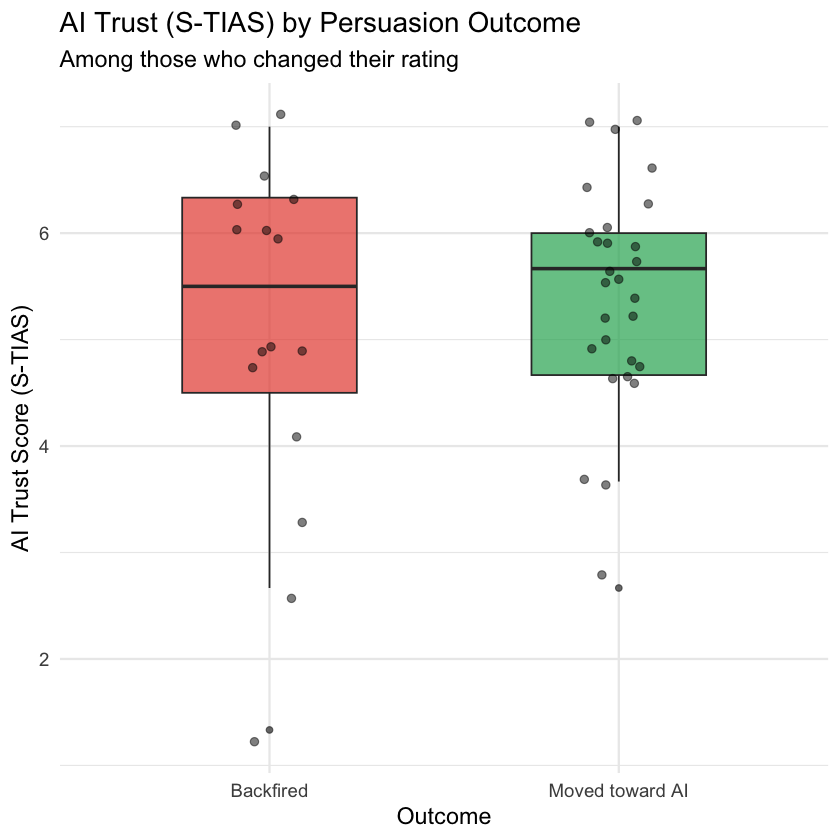

In [3]:
# Correlation: Outcome and AI Trust (S-TIAS)
# Filter to cases where change occurred (exclude No Change)
outcome_trust <- data_chat_analysis %>%
  filter(outcome %in% c("Moved toward AI", "Backfired")) %>%
  dplyr::select(participant_id, outcome, debrief_stias_average) %>%
  filter(!is.na(debrief_stias_average))

# Summary by outcome
trust_by_outcome <- outcome_trust %>%
  group_by(outcome) %>%
  summarise(
    n = n(),
    mean_trust = round(mean(debrief_stias_average), 2),
    median_trust = round(median(debrief_stias_average), 2),
    sd_trust = round(sd(debrief_stias_average), 2),
    .groups = "drop"
  )

message("AI Trust (S-TIAS) by Outcome:")
trust_by_outcome

# Statistical test (t-test)
moved <- outcome_trust %>% filter(outcome == "Moved toward AI") %>% pull(debrief_stias_average)
backfired <- outcome_trust %>% filter(outcome == "Backfired") %>% pull(debrief_stias_average)

if (length(moved) > 1 & length(backfired) > 1) {
  t_result <- t.test(moved, backfired)
  message(sprintf("\nt-test: t = %.2f, p = %.3f", t_result$statistic, t_result$p.value))
}

# Visualization
ggplot(outcome_trust, aes(x = outcome, y = debrief_stias_average, fill = outcome)) +
  geom_boxplot(width = 0.5, alpha = 0.7) +
  geom_jitter(width = 0.1, alpha = 0.5, size = 2) +
  scale_fill_manual(values = c(
    "Moved toward AI" = "#27AE60",
    "Backfired" = "#E74C3C"
  )) +
  labs(
    title = "AI Trust (S-TIAS) by Persuasion Outcome",
    subtitle = "Among those who changed their rating",
    x = "Outcome",
    y = "AI Trust Score (S-TIAS)",
    fill = "Outcome"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

In [4]:
# Correlations: Outcome vs other variables
# Use ALL cases with binary outcome: Persuaded vs Not Persuaded
outcome_data <- data_chat_analysis %>%
mutate(
  persuaded = ifelse(outcome == "Moved toward AI", "Persuaded", "Not Persuaded"),
  persuaded = factor(persuaded, levels = c("Persuaded", "Not Persuaded"))
)

# Join personality data
outcome_data <- outcome_data %>%
left_join(
  data %>% dplyr::select(participant_id,
                  tipi_extraversion, tipi_agreeableness, tipi_conscientiousness,
                  tipi_emotional_stability, tipi_openness,
                  debrief_ai_usage_frequency),
  by = "participant_id"
)

# 1. Age by outcome
message("=== AGE ===")
outcome_data %>%
group_by(persuaded) %>%
summarise(n = n(), mean_age = round(mean(demographics_age, na.rm = TRUE), 1),
          median_age = median(demographics_age, na.rm = TRUE), .groups = "drop")

# 2. Big Five personality traits
message("\n=== PERSONALITY (Big Five) ===")
personality_by_outcome <- outcome_data %>%
group_by(persuaded) %>%
summarise(
  n = n(),
  extraversion = round((mean(tipi_extraversion, na.rm = TRUE) - 1) / 6 * 100, 1),
  agreeableness = round((mean(tipi_agreeableness, na.rm = TRUE) - 1) / 6 * 100, 1),
  conscientiousness = round((mean(tipi_conscientiousness, na.rm = TRUE) - 1) / 6 * 100, 1),
  emotional_stability = round((mean(tipi_emotional_stability, na.rm = TRUE) - 1) / 6 * 100, 1),
  openness = round((mean(tipi_openness, na.rm = TRUE) - 1) / 6 * 100, 1),
  .groups = "drop"
)
message("(Values shown as percentages: 0% = lowest, 100% = highest)")
personality_by_outcome

# 3. Education
message("\n=== EDUCATION ===")
outcome_data %>%
count(persuaded, demographics_education) %>%
group_by(persuaded) %>%
mutate(pct = round(n / sum(n) * 100, 1)) %>%
pivot_wider(names_from = persuaded, values_from = c(n, pct))

# 4. AI usage frequency
message("\n=== AI USAGE FREQUENCY ===")
outcome_data %>%
count(persuaded, debrief_ai_usage_frequency) %>%
group_by(persuaded) %>%
mutate(pct = round(n / sum(n) * 100, 1)) %>%
pivot_wider(names_from = persuaded, values_from = c(n, pct))

# 5. Noticed persuasion
message("\n=== NOTICED PERSUASION ===")
outcome_data %>%
count(persuaded, debrief_noticed_persuasion) %>%
group_by(persuaded) %>%
mutate(pct = round(n / sum(n) * 100, 1)) %>%
pivot_wider(names_from = persuaded, values_from = c(n, pct))


=== AGE ===



persuaded,n,mean_age,median_age
<fct>,<int>,<dbl>,<dbl>
Persuaded,28,36,35.5
Not Persuaded,68,38,36.0



=== PERSONALITY (Big Five) ===

(Values shown as percentages: 0% = lowest, 100% = highest)



persuaded,n,extraversion,agreeableness,conscientiousness,emotional_stability,openness
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Persuaded,28,39.3,74.4,82.1,57.1,76.8
Not Persuaded,68,39.7,83.1,84.3,65.2,74.3



=== EDUCATION ===



demographics_education,n_Persuaded,n_Not Persuaded,pct_Persuaded,pct_Not Persuaded
<chr>,<int>,<int>,<dbl>,<dbl>
bachelor,15,25,53.6,36.8
doctorate,1,3,3.6,4.4
high_school,4,8,14.3,11.8
master,6,14,21.4,20.6
some_college,2,18,7.1,26.5



=== AI USAGE FREQUENCY ===



debrief_ai_usage_frequency,n_Persuaded,n_Not Persuaded,pct_Persuaded,pct_Not Persuaded
<chr>,<int>,<int>,<dbl>,<dbl>
often,11,37,39.3,54.4
sometimes,9,19,32.1,27.9
very_often,8,12,28.6,17.6



=== NOTICED PERSUASION ===



debrief_noticed_persuasion,n_Persuaded,n_Not Persuaded,pct_Persuaded,pct_Not Persuaded
<lgl>,<int>,<int>,<dbl>,<dbl>
FALSE,5,15,17.9,22.1
TRUE,23,53,82.1,77.9


## Within-Participant Patterns

Participant outcome patterns:



pattern,n,pct
<chr>,<int>,<dbl>
Mixed (both),7,29.2
No change only,2,8.3
Only backfired,5,20.8
Only toward AI,10,41.7


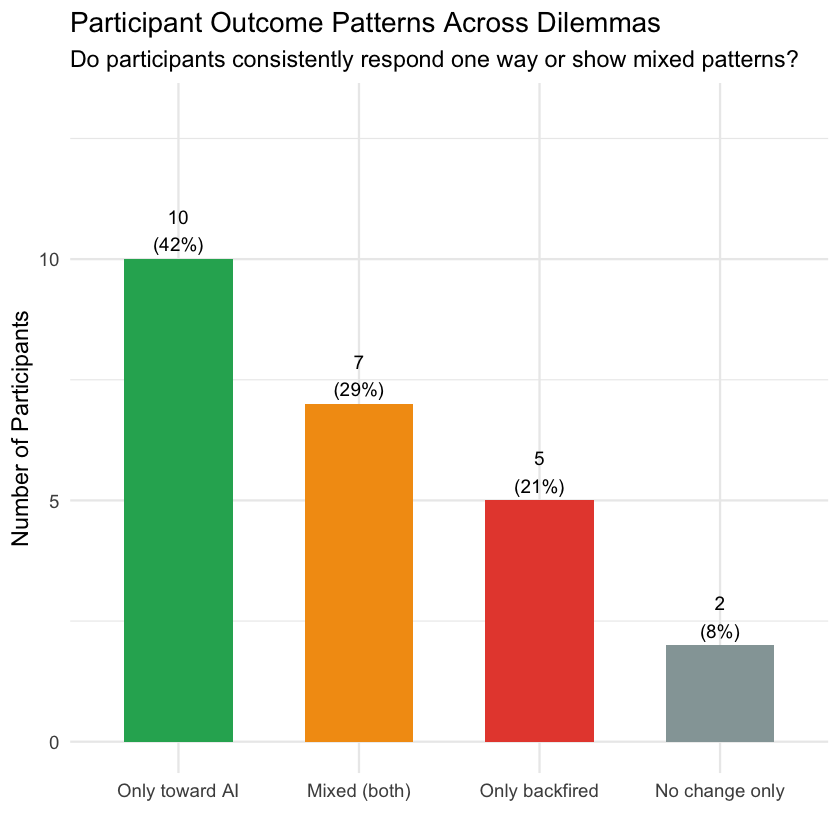

In [5]:
# Within-participant patterns: Do people both move toward AI AND backfire?

# Categorize each participant by their pattern of outcomes
participant_patterns <- data_chat_analysis %>%
  group_by(participant_id) %>%
  summarise(
    n_dilemmas = n(),
    n_toward_ai = sum(outcome == "Moved toward AI"),
    n_backfired = sum(outcome == "Backfired"),
    n_no_change = sum(outcome == "No Change"),
    has_toward_ai = n_toward_ai > 0,
    has_backfired = n_backfired > 0,
    pattern = case_when(
      has_toward_ai & has_backfired ~ "Mixed (both)",
      has_toward_ai & !has_backfired ~ "Only toward AI",
      !has_toward_ai & has_backfired ~ "Only backfired",
      TRUE ~ "No change only"
    ),
    .groups = "drop"
  )

message("Participant outcome patterns:")
participant_patterns %>%
  count(pattern) %>%
  mutate(pct = round(n / sum(n) * 100, 1))

# Visualization
pattern_summary <- participant_patterns %>%
  count(pattern) %>%
  mutate(pct = n / sum(n) * 100,
         pattern = factor(pattern, levels = c("Only toward AI", "Mixed (both)", "Only backfired", "No change only")))

ggplot(pattern_summary, aes(x = pattern, y = n, fill = pattern)) +
  geom_col(width = 0.6) +
  geom_text(aes(label = sprintf("%d\n(%.0f%%)", n, pct)), vjust = -0.2, size = 4) +
  scale_fill_manual(values = c(
    "Only toward AI" = "#27AE60",
    "Mixed (both)" = "#F39C12",
    "Only backfired" = "#E74C3C",
    "No change only" = "#95A5A6"
  )) +
  labs(
    title = "Participant Outcome Patterns Across Dilemmas",
    subtitle = "Do participants consistently respond one way or show mixed patterns?",
    x = "",
    y = "Number of Participants"
  ) +
  ylim(0, max(pattern_summary$n) * 1.3) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

## Dilemma Type Analysis

In [7]:
# Add dilemma metadata derived from dilemma names (consistent with 06_mixed_effects.ipynb)
data_with_type <- data_chat_analysis %>%
mutate(
  # Author: G_ = Greene, K_ = Koerner
  author = case_when(
    grepl("^G_", dilemma) ~ "Greene",
    grepl("^K_", dilemma) ~ "Koerner"
  ),
  # Category: G_P = Personal, G_I = Impersonal, K_ = Koerner
  category = case_when(
    grepl("^G_P", dilemma) ~ "Personal",
    grepl("^G_I", dilemma) ~ "Impersonal",
    grepl("^K_", dilemma) ~ "Koerner"
  )
)

message(sprintf("data_with_type: %d rows", nrow(data_with_type)))
message(sprintf("With author info: %d", sum(!is.na(data_with_type$author))))

data_with_type: 96 rows

With author info: 96




Overall ethical leaning distribution:



phase,leaning,n,pct
<fct>,<fct>,<int>,<dbl>
Post,Deontological,99,51.6
Post,Neutral,29,15.1
Post,Utilitarian,64,33.3
Pre,Deontological,105,54.7
Pre,Neutral,25,13.0
Pre,Utilitarian,62,32.3


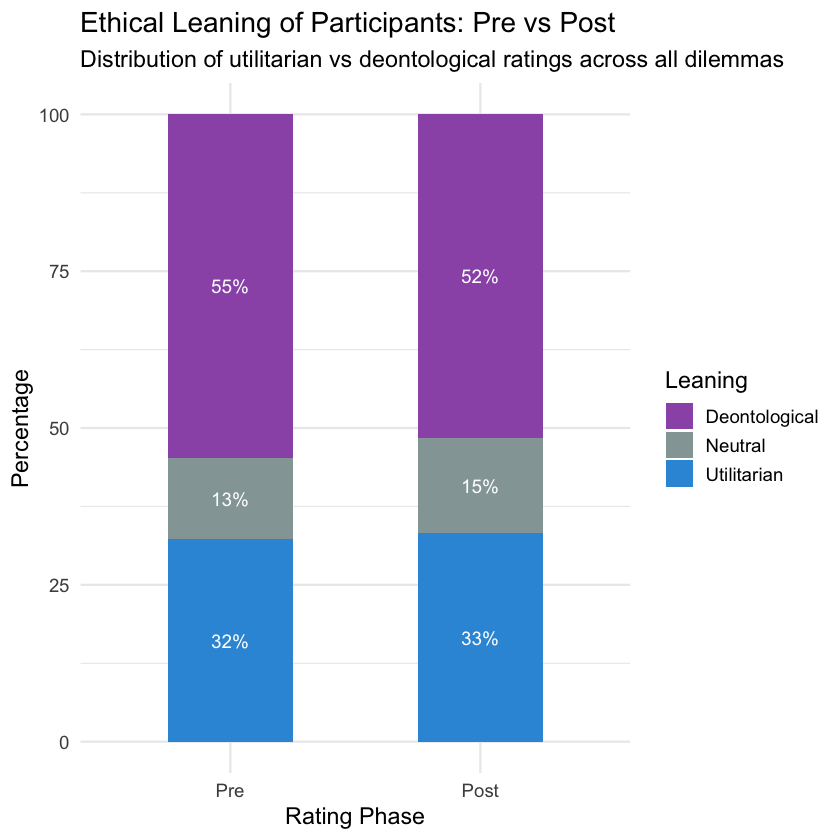

In [8]:
# Ethical leaning of participants: Pre vs Post ratings
# Classify each rating as utilitarian, deontological, or neutral based on low_rating_framework

participant_ethics <- data_long %>%
  filter(!is.na(low_rating_framework)) %>%
  mutate(
    # Classify pre-rating
    pre_leaning = case_when(
      rating_pre == 4 ~ "Neutral",
      rating_pre < 4 & low_rating_framework == "utilitarian" ~ "Utilitarian",
      rating_pre < 4 & low_rating_framework == "deontological" ~ "Deontological",
      rating_pre > 4 & low_rating_framework == "utilitarian" ~ "Deontological",
      rating_pre > 4 & low_rating_framework == "deontological" ~ "Utilitarian"
    ),
    # Classify post-rating
    post_leaning = case_when(
      rating_post == 4 ~ "Neutral",
      rating_post < 4 & low_rating_framework == "utilitarian" ~ "Utilitarian",
      rating_post < 4 & low_rating_framework == "deontological" ~ "Deontological",
      rating_post > 4 & low_rating_framework == "utilitarian" ~ "Deontological",
      rating_post > 4 & low_rating_framework == "deontological" ~ "Utilitarian"
    )
  )

# Per-participant summary
participant_ethics_summary <- participant_ethics %>%
  group_by(participant_id) %>%
  summarise(
    n_ratings = n(),
    # Pre-rating breakdown
    pre_utilitarian = sum(pre_leaning == "Utilitarian"),
    pre_deontological = sum(pre_leaning == "Deontological"),
    pre_neutral = sum(pre_leaning == "Neutral"),
    pre_pct_utilitarian = round(pre_utilitarian / n_ratings * 100, 1),
    pre_pct_deontological = round(pre_deontological / n_ratings * 100, 1),
    # Post-rating breakdown
    post_utilitarian = sum(post_leaning == "Utilitarian"),
    post_deontological = sum(post_leaning == "Deontological"),
    post_neutral = sum(post_leaning == "Neutral"),
    post_pct_utilitarian = round(post_utilitarian / n_ratings * 100, 1),
    post_pct_deontological = round(post_deontological / n_ratings * 100, 1),
    .groups = "drop"
  )

# Overall summary
overall_ethics <- participant_ethics %>%
  pivot_longer(cols = c(pre_leaning, post_leaning), 
               names_to = "phase", values_to = "leaning") %>%
  mutate(phase = ifelse(phase == "pre_leaning", "Pre", "Post")) %>%
  count(phase, leaning) %>%
  group_by(phase) %>%
  mutate(pct = round(n / sum(n) * 100, 1)) %>%
  ungroup() %>%
  mutate(
    phase = factor(phase, levels = c("Pre", "Post")),
    leaning = factor(leaning, levels = c("Deontological", "Neutral", "Utilitarian"))
  )

message("\nOverall ethical leaning distribution:")
overall_ethics

# Visualization
ggplot(overall_ethics, aes(x = phase, y = pct, fill = leaning)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")), 
            position = position_stack(vjust = 0.5), size = 4, color = "white") +
  scale_fill_manual(values = c(
    "Utilitarian" = "#3498DB",
    "Neutral" = "#95A5A6",
    "Deontological" = "#9B59B6"
  )) +
  labs(
    title = "Ethical Leaning of Participants: Pre vs Post",
    subtitle = "Distribution of utilitarian vs deontological ratings across all dilemmas",
    x = "Rating Phase",
    y = "Percentage",
    fill = "Leaning"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

In [9]:
# Transform ratings to consistent scale: 1=deontological, 7=utilitarian
participant_ethics_score <- data_long %>%
filter(!is.na(low_rating_framework)) %>%
mutate(
  # Flip ratings where low=utilitarian so all are on same scale
  rating_normalized = case_when(
    low_rating_framework == "utilitarian" ~ 8 - rating_pre,  # Flip: 1→7, 7→1
    low_rating_framework == "deontological" ~ rating_pre     # Keep as is
  )
  # Now for all dilemmas: 1=deontological, 7=utilitarian
) %>%
group_by(participant_id) %>%
summarise(
  ethics_score = mean(rating_normalized, na.rm = TRUE),
  .groups = "drop"
)

# Median split
median_score <- median(participant_ethics_score$ethics_score)
  participant_ethics_score <- participant_ethics_score %>%
    mutate(
      ethics_group = ifelse(ntile(ethics_score, 2) == 1, "Deontological", "Utilitarian")
    )



message(sprintf("Ethics score range: %.2f to %.2f",
              min(participant_ethics_score$ethics_score),
              max(participant_ethics_score$ethics_score)))
message(sprintf("Median: %.2f", median_score))
message(sprintf("Utilitarian group: %d, Deontological group: %d",
              sum(participant_ethics_score$ethics_group == "Utilitarian"),
              sum(participant_ethics_score$ethics_group == "Deontological")))

# Join to chat data and compare
ethics_persuasion <- data_chat_analysis %>%
mutate(
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  )
) %>%
left_join(participant_ethics_score, by = "participant_id")

# Compare groups
message("\n=== Movement Toward AI by Ethics Group ===")
ethics_persuasion %>%
group_by(ethics_group) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  sd = sd(movement_toward_ai),
  .groups = "drop"
) %>%
print()

# T-test
t_res <- t.test(movement_toward_ai ~ ethics_group, data = ethics_persuasion)
message(sprintf("\nt-test: t=%.2f, df=%.1f, p=%.4f %s",
              t_res$statistic, t_res$parameter, t_res$p.value,
              ifelse(t_res$p.value < 0.05, "*", "")))


Ethics score range: 2.25 to 4.75

Median: 3.38

Utilitarian group: 12, Deontological group: 12


=== Movement Toward AI by Ethics Group ===



# A tibble: 2 × 4
  ethics_group      n mean_movement    sd
  <chr>         <int>         <dbl> <dbl>
1 Deontological    48         0.271  1.63
2 Utilitarian      48         0.417  1.91



t-test: t=-0.40, df=91.8, p=0.6887 




=== ETHICAL FRAMEWORK × LLM PROVIDER ===

Summary:



# A tibble: 4 × 7
  llm_label llm_framework     n mean_movement median_movement sd_movement
  <fct>     <fct>         <int>         <dbl>           <dbl>       <dbl>
1 Claude    Deontological    28        0.357                0        1.52
2 Claude    Utilitarian      16        1.44                 1        1.97
3 Qwen      Deontological    25       -0.0400               0        1.93
4 Qwen      Utilitarian      27        0.0370               0        1.56
# ℹ 1 more variable: se_movement <dbl>



Overall: Kruskal-Wallis H=8.21, p=0.0418 *


Framework comparisons (by LLM):

  Claude (Deontological vs Utilitarian): mean=0.36 vs 1.44, W=148, p=0.0470 *

  Qwen (Deontological vs Utilitarian): mean=-0.04 vs 0.04, W=348, p=0.8304 


Claude vs Qwen (by Framework):

  Deontological: mean=0.36 vs -0.04, W=380, p=0.5685 

  Utilitarian: mean=1.44 vs 0.04, W=312, p=0.0079 *



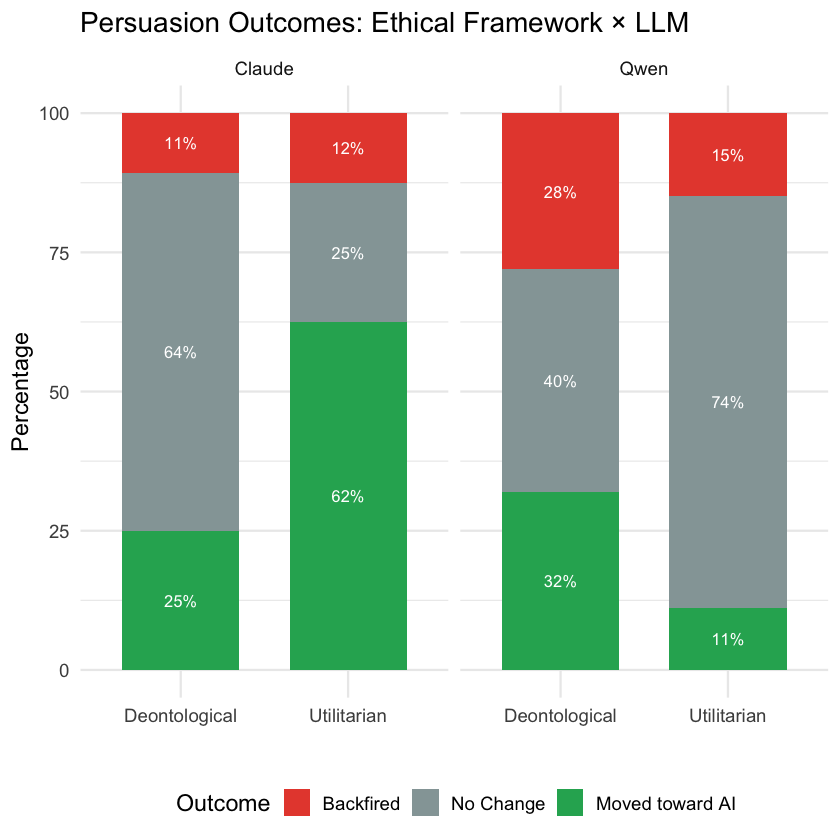

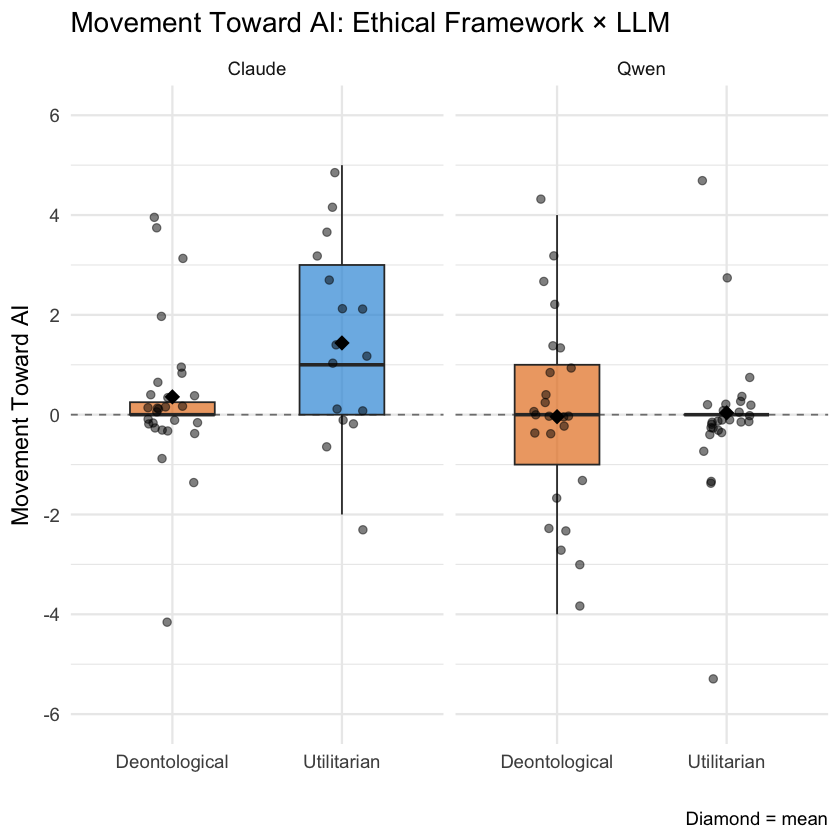

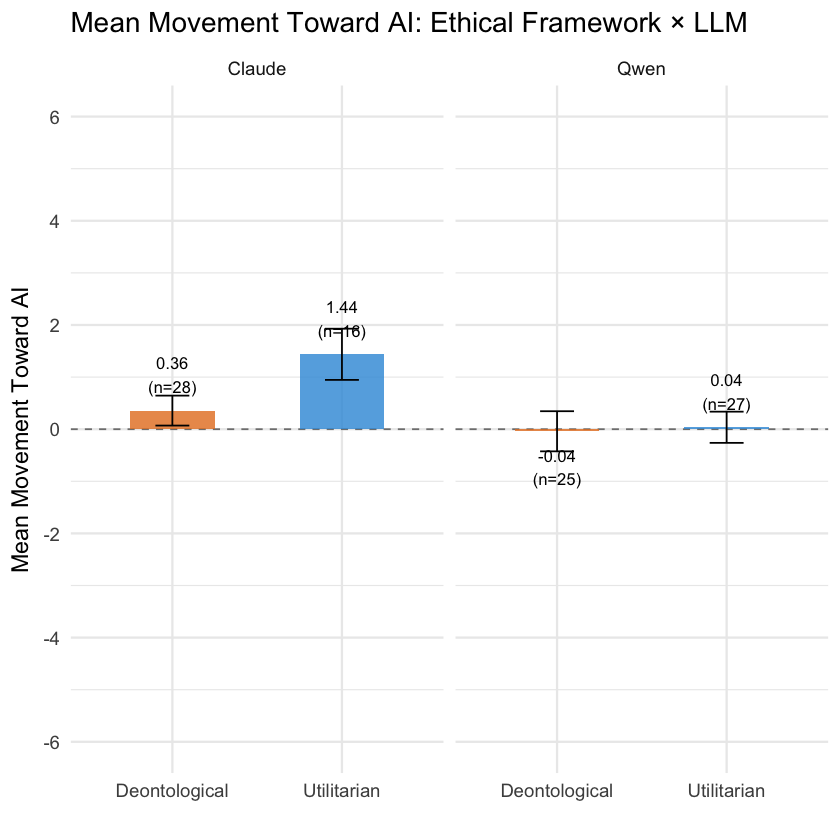

In [10]:

message("\n=== ETHICAL FRAMEWORK × LLM PROVIDER ===")

framework_llm_data <- data_chat_analysis %>%
filter(!is.na(llm_framework)) %>%
mutate(
  llm_framework = str_to_title(llm_framework),
  llm_framework = factor(llm_framework),
  llm_label = ifelse(llm_provider == "anthropic", "Claude", "Qwen"),
  llm_label = factor(llm_label, levels = c("Claude", "Qwen")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI")),
  group = paste(llm_label, llm_framework, sep = " × ")
)

# Summary stats
framework_llm_stats <- framework_llm_data %>%
group_by(llm_label, llm_framework) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(framework_llm_stats)

# Overall Kruskal-Wallis (all groups)
kruskal_res <- kruskal.test(movement_toward_ai ~ group, data = framework_llm_data)
message(sprintf("\nOverall: Kruskal-Wallis H=%.2f, p=%.4f %s",
              kruskal_res$statistic, kruskal_res$p.value,
              ifelse(kruskal_res$p.value < 0.05, "*", "")))

# Framework comparisons within each LLM
message("\nFramework comparisons (by LLM):")
for (llm in c("Claude", "Qwen")) {
llm_data <- framework_llm_data %>% filter(llm_label == llm)
frameworks <- unique(llm_data$llm_framework)

if (length(frameworks) >= 2) {
  data1 <- llm_data %>% filter(llm_framework == frameworks[1]) %>% pull(movement_toward_ai)
  data2 <- llm_data %>% filter(llm_framework == frameworks[2]) %>% pull(movement_toward_ai)

  if (length(data1) >= 2 && length(data2) >= 2) {
    wilcox_res <- wilcox.test(data1, data2, exact = FALSE)
    message(sprintf("  %s (%s vs %s): mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                    llm, frameworks[1], frameworks[2],
                    mean(data1), mean(data2),
                    wilcox_res$statistic, wilcox_res$p.value,
                    ifelse(wilcox_res$p.value < 0.05, "*", "")))
  }
}
}

# LLM comparisons within each framework
message("\nClaude vs Qwen (by Framework):")
for (fw in unique(framework_llm_data$llm_framework)) {
claude_data <- framework_llm_data %>% filter(llm_label == "Claude", llm_framework == fw) %>% pull(movement_toward_ai)
qwen_data <- framework_llm_data %>% filter(llm_label == "Qwen", llm_framework == fw) %>% pull(movement_toward_ai)

if (length(claude_data) >= 2 && length(qwen_data) >= 2) {
  wilcox_res <- wilcox.test(claude_data, qwen_data, exact = FALSE)
  message(sprintf("  %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                  fw, mean(claude_data), mean(qwen_data),
                  wilcox_res$statistic, wilcox_res$p.value,
                  ifelse(wilcox_res$p.value < 0.05, "*", "")))
}
}

# Outcome percentages for stacked bar
framework_llm_outcomes <- framework_llm_data %>%
count(llm_label, llm_framework, outcome) %>%
group_by(llm_label, llm_framework) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

# 1. Stacked bar chart
ggplot(framework_llm_outcomes, aes(x = llm_framework, y = pct, fill = outcome)) +
geom_col(width = 0.7) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 3.5, color = "white") +
facet_wrap(~llm_label) +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes: Ethical Framework × LLM",
     x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "bottom")

# 2. Boxplot
ggplot(framework_llm_data, aes(x = llm_framework, y = movement_toward_ai, fill = llm_framework)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
facet_wrap(~llm_label) +
scale_fill_manual(values = c("Utilitarian" = "#3498DB", "Deontological" = "#E67E22")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI: Ethical Framework × LLM",
     x = "", y = "Movement Toward AI", caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(framework_llm_stats, aes(x = llm_framework, y = mean_movement, fill = llm_framework)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(framework_llm_stats$mean_movement >= 0, -0.5, 1.5), size = 3.5) +
facet_wrap(~llm_label) +
scale_fill_manual(values = c("Utilitarian" = "#3498DB", "Deontological" = "#E67E22")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI: Ethical Framework × LLM",
     x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")



=== OUTCOMES BY DILEMMA AUTHOR ===

Summary:



# A tibble: 2 × 6
  author      n mean_movement median_movement sd_movement se_movement
  <fct>   <int>         <dbl>           <dbl>       <dbl>       <dbl>
1 Greene     48         0.208               0        1.54       0.223
2 Koerner    48         0.479               0        1.98       0.286



Greene vs Koerner: mean=0.21 vs 0.48, W=1086, p=0.6030 


Binomial tests (H0: p=0.5, among those who changed):

  Greene: 13/21 (61.9%), p=0.1917 

  Koerner: 15/23 (65.2%), p=0.1050 



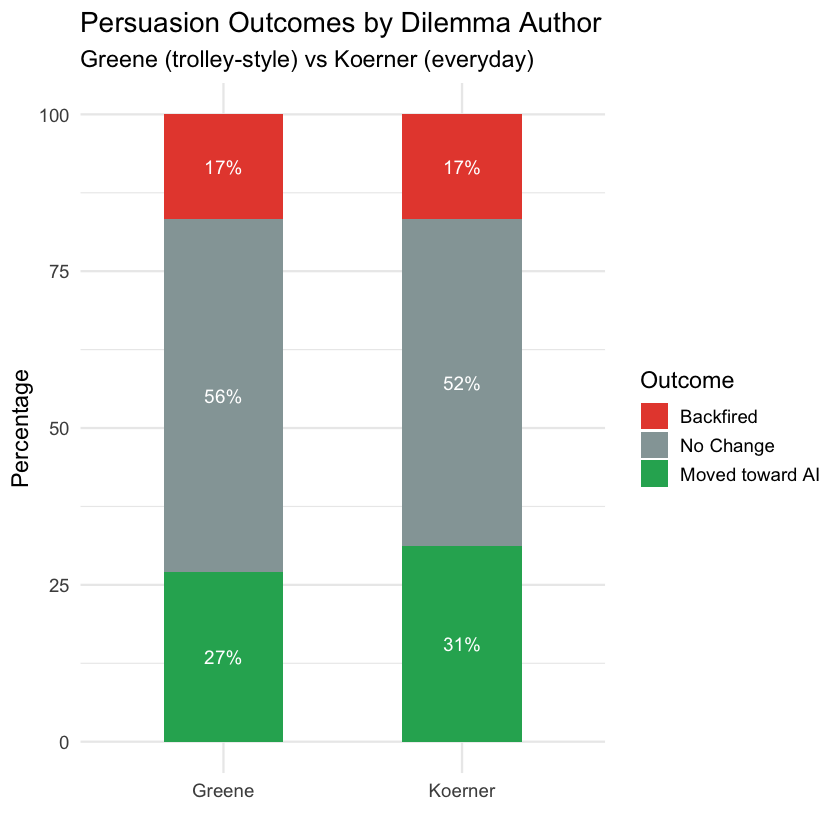

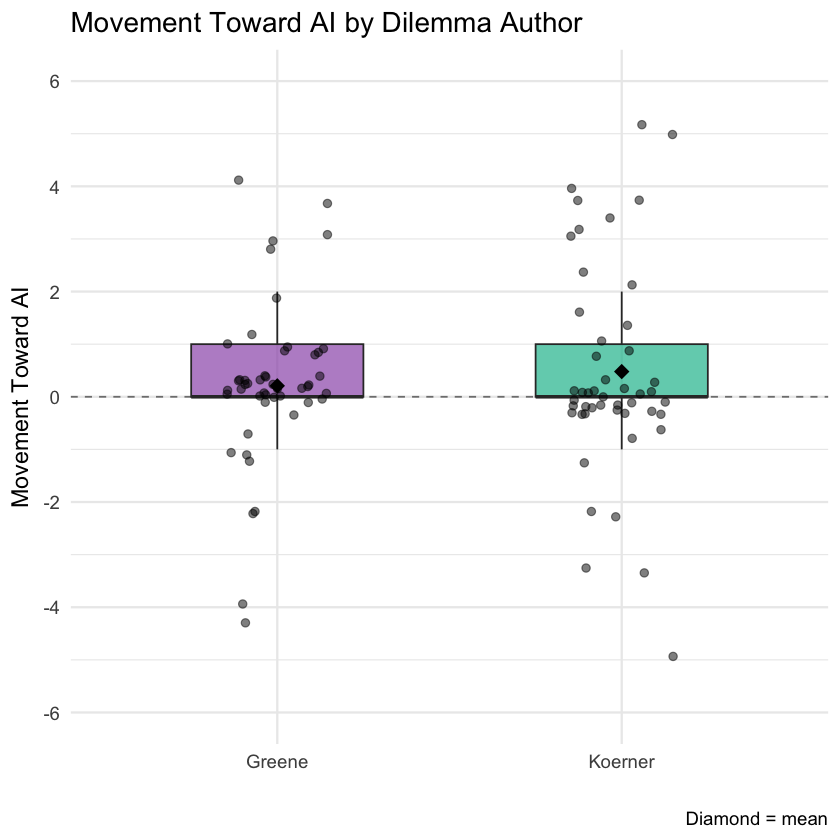

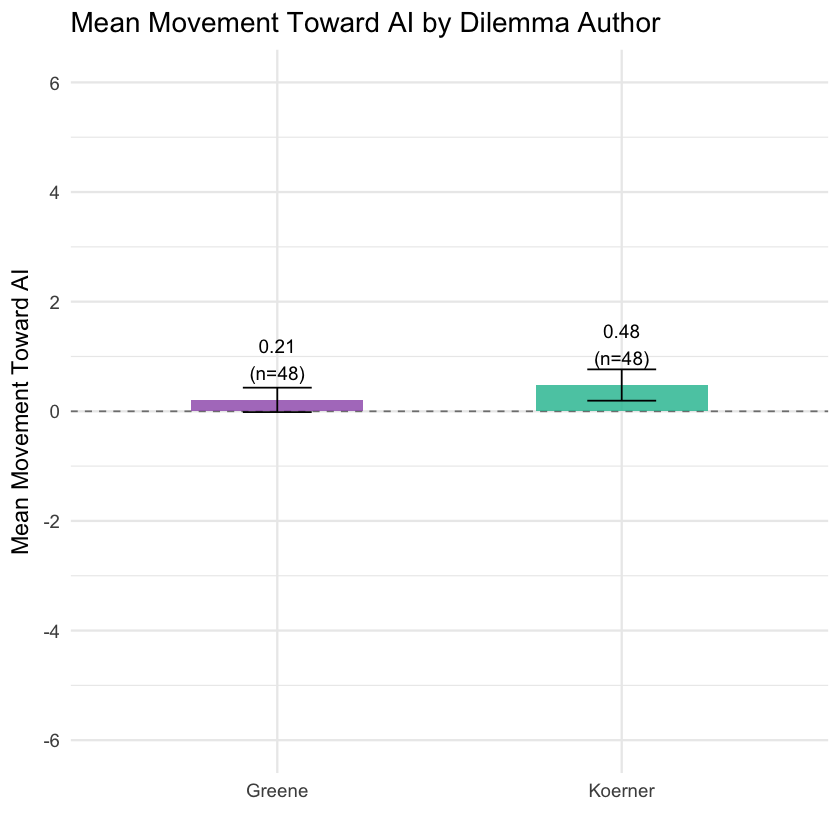

In [11]:

message("\n=== OUTCOMES BY DILEMMA AUTHOR ===")

author_data <- data_with_type %>%
filter(!is.na(author)) %>%
mutate(
  author = str_to_title(author),
  author = factor(author, levels = c("Greene", "Koerner")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
)

# Summary stats
author_stats <- author_data %>%
group_by(author) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(author_stats)

# Wilcoxon test
greene_movement <- author_data %>% filter(author == "Greene") %>% pull(movement_toward_ai)
koerner_movement <- author_data %>% filter(author == "Koerner") %>% pull(movement_toward_ai)

wilcox_res <- wilcox.test(greene_movement, koerner_movement, exact = FALSE)
message(sprintf("\nGreene vs Koerner: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
              mean(greene_movement), mean(koerner_movement),
              wilcox_res$statistic, wilcox_res$p.value,
              ifelse(wilcox_res$p.value < 0.05, "*", "")))

# Binomial tests (among those who changed)
message("\nBinomial tests (H0: p=0.5, among those who changed):")
for (auth in c("Greene", "Koerner")) {
auth_changed <- author_data %>%
  filter(author == auth, outcome %in% c("Moved toward AI", "Backfired"))
n_moved <- sum(auth_changed$outcome == "Moved toward AI")
n_total <- nrow(auth_changed)

if (n_total >= 2) {
  binom_res <- binom.test(n_moved, n_total, p = 0.5, alternative = "greater")
  message(sprintf("  %s: %d/%d (%.1f%%), p=%.4f %s",
                  auth, n_moved, n_total, n_moved/n_total*100, binom_res$p.value,
                  ifelse(binom_res$p.value < 0.05, "*", "")))
}
}

# Outcome percentages for stacked bar
author_outcomes <- author_data %>%
count(author, outcome) %>%
group_by(author) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

# 1. Stacked bar chart
ggplot(author_outcomes, aes(x = author, y = pct, fill = outcome)) +
geom_col(width = 0.5) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes by Dilemma Author",
     subtitle = "Greene (trolley-style) vs Koerner (everyday)",
     x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot
ggplot(author_data, aes(x = author, y = movement_toward_ai, fill = author)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
scale_fill_manual(values = c("Greene" = "#9B59B6", "Koerner" = "#1ABC9C")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI by Dilemma Author",
     x = "", y = "Movement Toward AI", caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(author_stats, aes(x = author, y = mean_movement, fill = author)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(author_stats$mean_movement >= 0, -0.5, 1.5), size = 4) +
scale_fill_manual(values = c("Greene" = "#9B59B6", "Koerner" = "#1ABC9C")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI by Dilemma Author",
     x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")



=== OUTCOMES BY KOERNER DILEMMA VARIATION ===


Kruskal-Wallis: H=2.73, p=0.4358 


Pairwise comparisons:

  BS Prohibition vs BG Prohibition: mean=0.45 vs 0.69, W=70, p=0.9742 

  BS Prohibition vs BS Prescription: mean=0.45 vs 1.18, W=49, p=0.4298 

  BS Prohibition vs BG Prescription: mean=0.45 vs -0.31, W=86, p=0.3932 

  BG Prohibition vs BS Prescription: mean=0.69 vs 1.18, W=58, p=0.4377 

  BG Prohibition vs BG Prescription: mean=0.69 vs -0.31, W=102, p=0.3371 

  BS Prescription vs BG Prescription: mean=1.18 vs -0.31, W=96, p=0.1516 



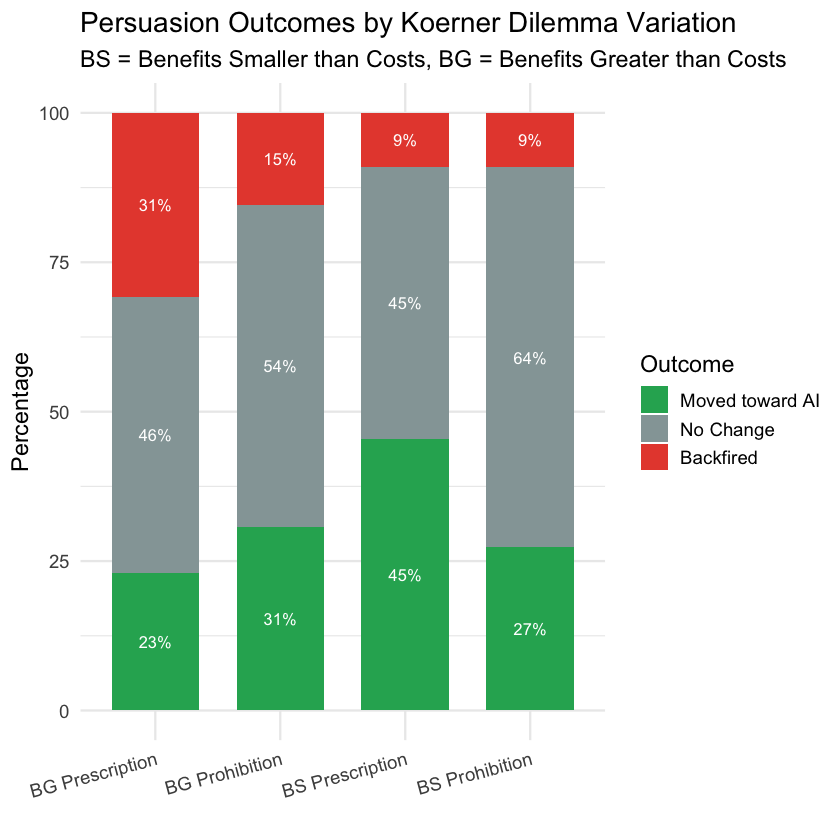

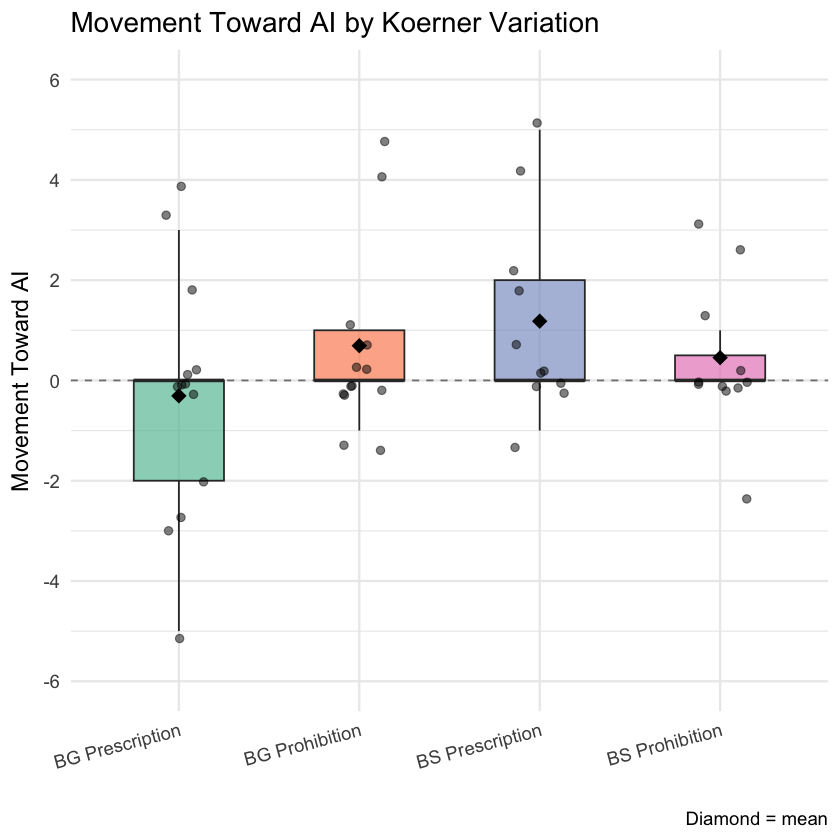

In [12]:
message("\n=== OUTCOMES BY KOERNER DILEMMA VARIATION ===")

# Create Koerner data with correct variation extraction
koerner_data <- data_chat_analysis %>%
filter(grepl("^K_", dilemma)) %>%
mutate(
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  # Extract variation from K_XXX_ prefix
  variation = str_extract(dilemma, "(?<=K_)[^_]+"),
  variation = factor(variation, levels = c("bsA", "bsO", "bgA", "bgO"),
                     labels = c("BS Action", "BS Omission", "BG Action", "BG Omission"))
)

 koerner_data <- data_chat_analysis %>%
    filter(grepl("^K_", dilemma)) %>%
    mutate(
      movement_toward_ai = case_when(
        outcome == "Moved toward AI" ~ abs(rating_change),
        outcome == "Backfired" ~ -abs(rating_change),
        TRUE ~ 0
      ),
      # Extract components
      benefits = ifelse(grepl("_bg", dilemma), "BG", "BS"),
      norm_type = ifelse(grepl("A_", dilemma), "Prohibition", "Prescription"),
      variation = paste(benefits, norm_type)
    )


# Kruskal-Wallis test
if (n_distinct(koerner_data$variation) > 1) {
kw_res <- kruskal.test(movement_toward_ai ~ variation, data = koerner_data)
message(sprintf("\nKruskal-Wallis: H=%.2f, p=%.4f %s",
                kw_res$statistic, kw_res$p.value,
                ifelse(kw_res$p.value < 0.05, "*", "")))
}

# Pairwise Wilcoxon
message("\nPairwise comparisons:")
variations <- c("BS Prohibition", "BG Prohibition", "BS Prescription", "BG Prescription")
for (i in 1:(length(variations)-1)) {
for (j in (i+1):length(variations)) {
  v1 <- variations[i]
  v2 <- variations[j]

  data1 <- koerner_data %>% filter(variation == v1) %>% pull(movement_toward_ai)
  data2 <- koerner_data %>% filter(variation == v2) %>% pull(movement_toward_ai)

  if (length(data1) >= 2 && length(data2) >= 2) {
    wilcox_res <- wilcox.test(data1, data2, exact = FALSE)
    message(sprintf("  %s vs %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                    v1, v2, mean(data1), mean(data2),
                    wilcox_res$statistic, wilcox_res$p.value,
                    ifelse(wilcox_res$p.value < 0.05, "*", "")))
  }
}
}

# Outcome percentages for stacked bar
koerner_outcomes <- koerner_data %>%
count(variation, outcome) %>%
group_by(variation) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

# 1. Stacked bar chart - outcomes

koerner_outcomes <- koerner_outcomes %>%
mutate(outcome = factor(outcome, levels = c("Moved toward AI", "No Change", "Backfired")))

ggplot(koerner_outcomes, aes(x = variation, y = pct, fill = outcome)) +
geom_col(width = 0.7, position = position_stack(reverse = TRUE)) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5, reverse = TRUE), size = 3.5, color = "white") +
scale_fill_manual(values = c("Moved toward AI" = "#27AE60", "No Change" = "#95A5A6", "Backfired" = "#E74C3C")) +
labs(
  title = "Persuasion Outcomes by Koerner Dilemma Variation",
  subtitle = "BS = Benefits Smaller than Costs, BG = Benefits Greater than Costs",
  x = "", y = "Percentage", fill = "Outcome"
) +
theme_minimal(base_size = 14) +
theme(legend.position = "right", axis.text.x = element_text(angle = 15, hjust = 1))



# 2. Boxplot - movement toward AI
ggplot(koerner_data, aes(x = variation, y = movement_toward_ai, fill = variation)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
scale_fill_brewer(palette = "Set2") +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI by Koerner Variation",
     x = "", y = "Movement Toward AI", caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none", axis.text.x = element_text(angle = 15, hjust = 1))



=== OUTCOMES BY DILEMMA TYPE ===

Summary:



# A tibble: 3 × 6
  category       n mean_movement median_movement sd_movement se_movement
  <fct>      <int>         <dbl>           <dbl>       <dbl>       <dbl>
1 Personal      24         0.167               0        1.69       0.344
2 Impersonal    24         0.25                0        1.42       0.290
3 Koerner       48         0.479               0        1.98       0.286



Overall: Kruskal-Wallis H=0.30, p=0.8596 


Pairwise comparisons:

  Personal vs Impersonal: mean=0.17 vs 0.25, W=280, p=0.8732 

  Personal vs Koerner: mean=0.17 vs 0.48, W=536, p=0.6154 

  Impersonal vs Koerner: mean=0.25 vs 0.48, W=550, p=0.7385 


Binomial tests (H0: p=0.5, among those who changed):

  Personal: 8/14 (57.1%), p=0.3953 

  Impersonal: 5/7 (71.4%), p=0.2266 

  Koerner: 15/23 (65.2%), p=0.1050 



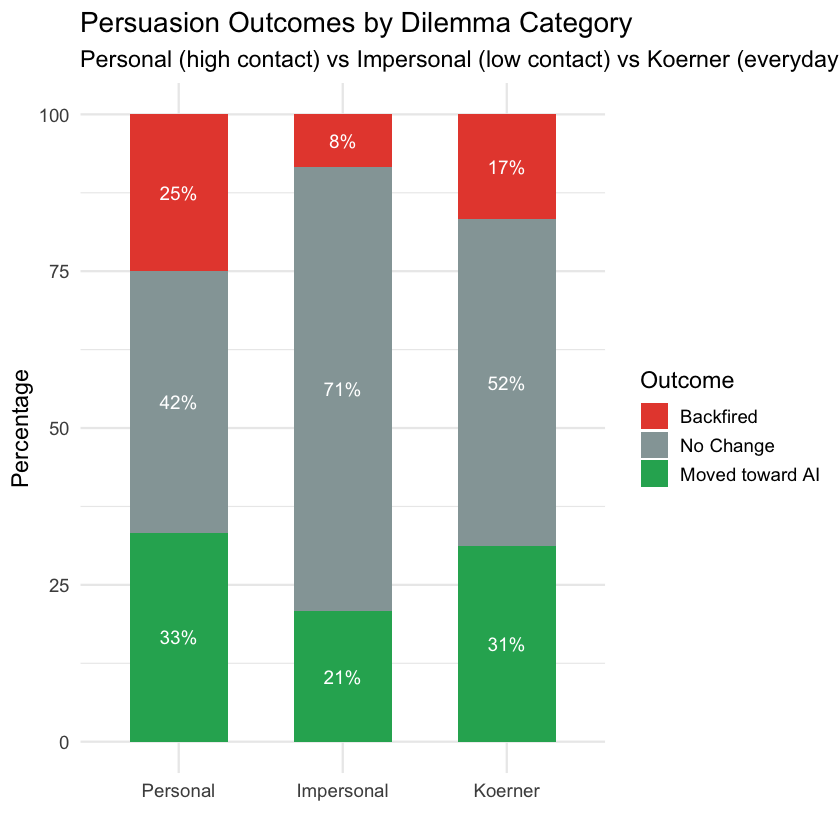

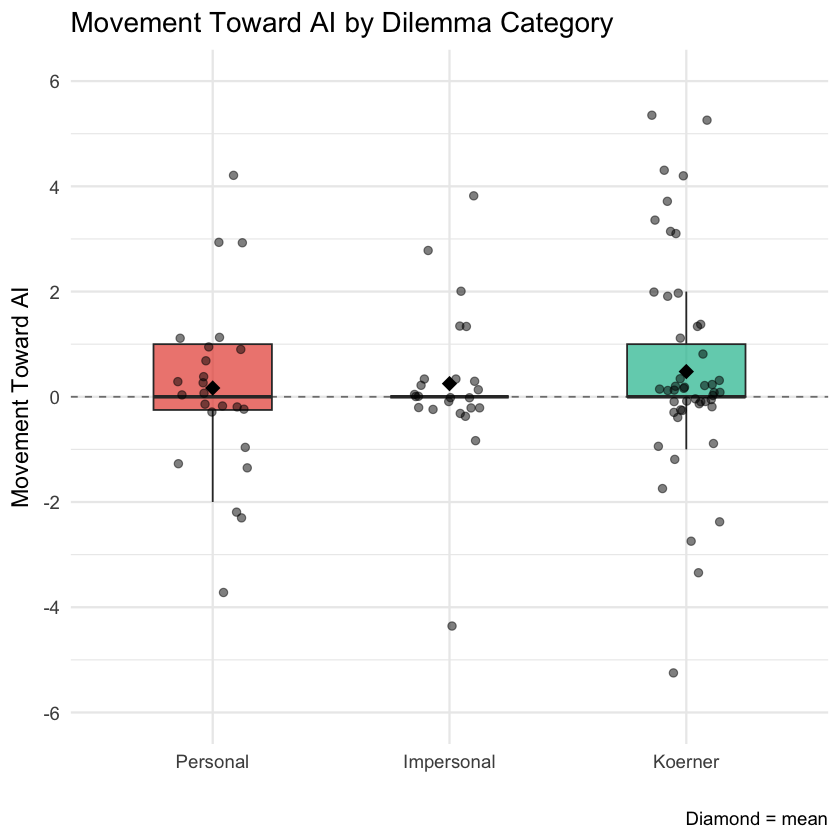

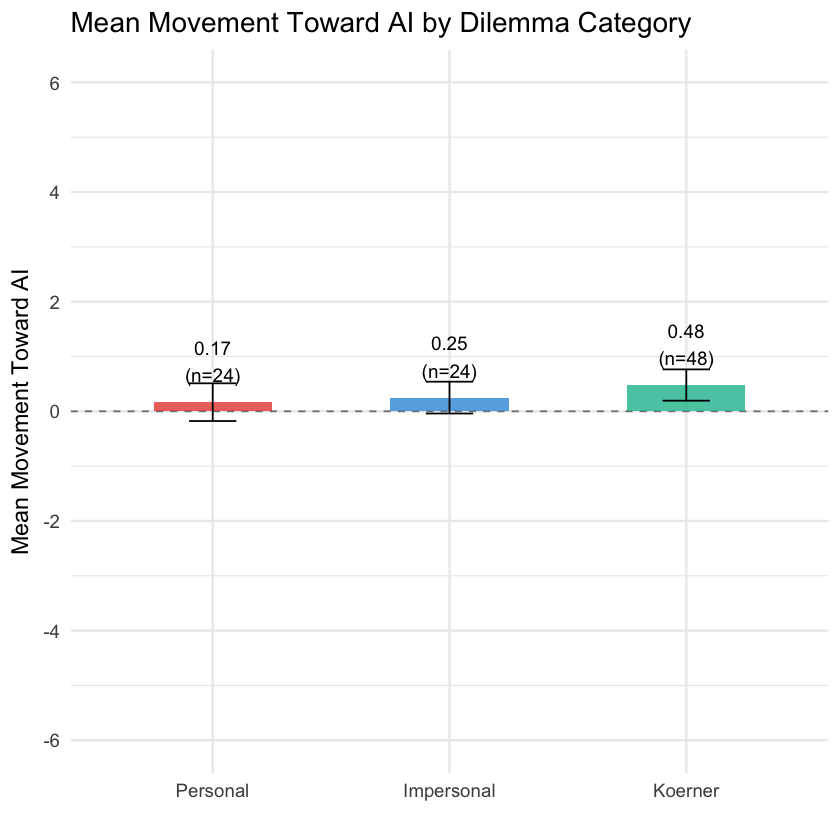

In [13]:
message("\n=== OUTCOMES BY DILEMMA TYPE ===")

dilemma_type_data <- data_with_type %>%
filter(!is.na(category)) %>%
mutate(
  category = str_to_title(category),
  category = factor(category, levels = c("Personal", "Impersonal", "Koerner")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
)

# Summary stats
dilemma_type_stats <- dilemma_type_data %>%
group_by(category) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(dilemma_type_stats)

# Kruskal-Wallis (overall)
kruskal_res <- kruskal.test(movement_toward_ai ~ category, data = dilemma_type_data)
message(sprintf("\nOverall: Kruskal-Wallis H=%.2f, p=%.4f %s",
              kruskal_res$statistic, kruskal_res$p.value,
              ifelse(kruskal_res$p.value < 0.05, "*", "")))

# Pairwise Wilcoxon
message("\nPairwise comparisons:")
types <- c("Personal", "Impersonal", "Koerner")
for (i in 1:(length(types)-1)) {
for (j in (i+1):length(types)) {
  t1 <- types[i]
  t2 <- types[j]

  data1 <- dilemma_type_data %>% filter(category == t1) %>% pull(movement_toward_ai)
  data2 <- dilemma_type_data %>% filter(category == t2) %>% pull(movement_toward_ai)

  if (length(data1) >= 2 && length(data2) >= 2) {
    wilcox_res <- wilcox.test(data1, data2, exact = FALSE)
    message(sprintf("  %s vs %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                    t1, t2, mean(data1), mean(data2),
                    wilcox_res$statistic, wilcox_res$p.value,
                    ifelse(wilcox_res$p.value < 0.05, "*", "")))
  }
}
}

# Binomial tests (among those who changed)
message("\nBinomial tests (H0: p=0.5, among those who changed):")
for (type in c("Personal", "Impersonal", "Koerner")) {
type_changed <- dilemma_type_data %>%
  filter(category == type, outcome %in% c("Moved toward AI", "Backfired"))
n_moved <- sum(type_changed$outcome == "Moved toward AI")
n_total <- nrow(type_changed)

if (n_total >= 2) {
  binom_res <- binom.test(n_moved, n_total, p = 0.5, alternative = "greater")
  message(sprintf("  %s: %d/%d (%.1f%%), p=%.4f %s",
                  type, n_moved, n_total, n_moved/n_total*100, binom_res$p.value,
                  ifelse(binom_res$p.value < 0.05, "*", "")))
}
}

# Outcome percentages for stacked bar
dilemma_type_outcomes <- dilemma_type_data %>%
count(category, outcome) %>%
group_by(category) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

# 1. Stacked bar chart
ggplot(dilemma_type_outcomes, aes(x = category, y = pct, fill = outcome)) +
geom_col(width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes by Dilemma Category",
     subtitle = "Personal (high contact) vs Impersonal (low contact) vs Koerner (everyday)",
     x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot
ggplot(dilemma_type_data, aes(x = category, y = movement_toward_ai, fill = category)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
scale_fill_manual(values = c("Personal" = "#E74C3C", "Impersonal" = "#3498DB", "Koerner" = "#1ABC9C")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI by Dilemma Category",
     x = "", y = "Movement Toward AI", caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(dilemma_type_stats, aes(x = category, y = mean_movement, fill = category)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(dilemma_type_stats$mean_movement >= 0, -0.5, 1.5), size = 4) +
scale_fill_manual(values = c("Personal" = "#E74C3C", "Impersonal" = "#3498DB", "Koerner" = "#1ABC9C")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI by Dilemma Category",
     x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")


# A tibble: 2 × 6
  dilemma_type     n mean_movement median_movement sd_movement se_movement
  <fct>        <int>         <dbl>           <dbl>       <dbl>       <dbl>
1 Action          48         0.438               0        1.43       0.206
2 Omission        48         0.25                0        2.07       0.298



Action vs Omission: W=1204, p=0.6774 

Action: 13/18 moved toward AI (72.2%), binomial p=0.0963 

Omission: 15/26 moved toward AI (57.7%), binomial p=0.5572 



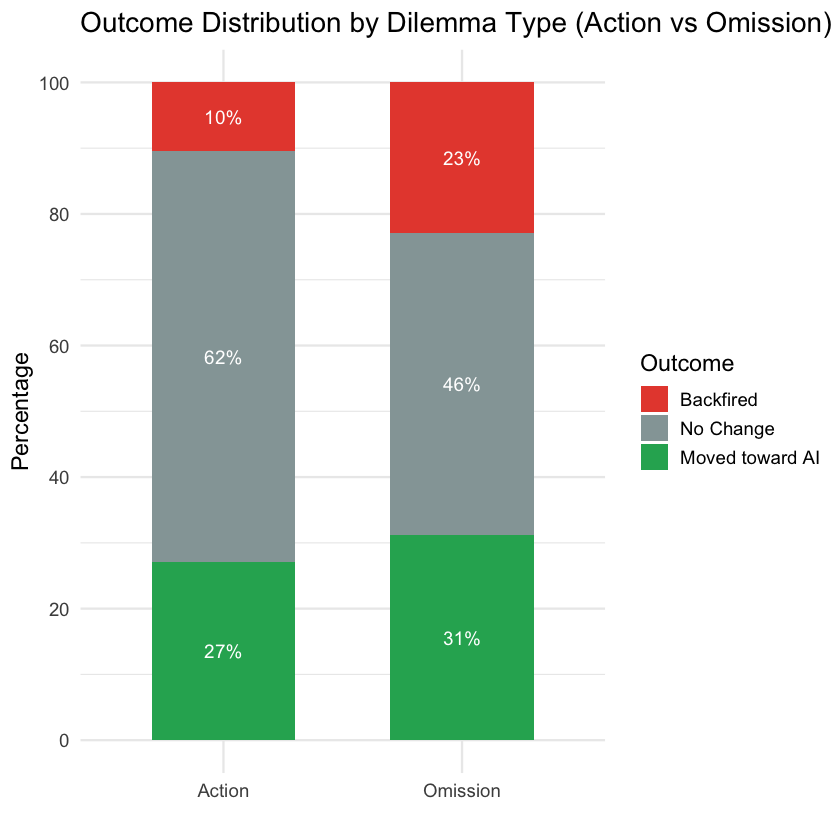

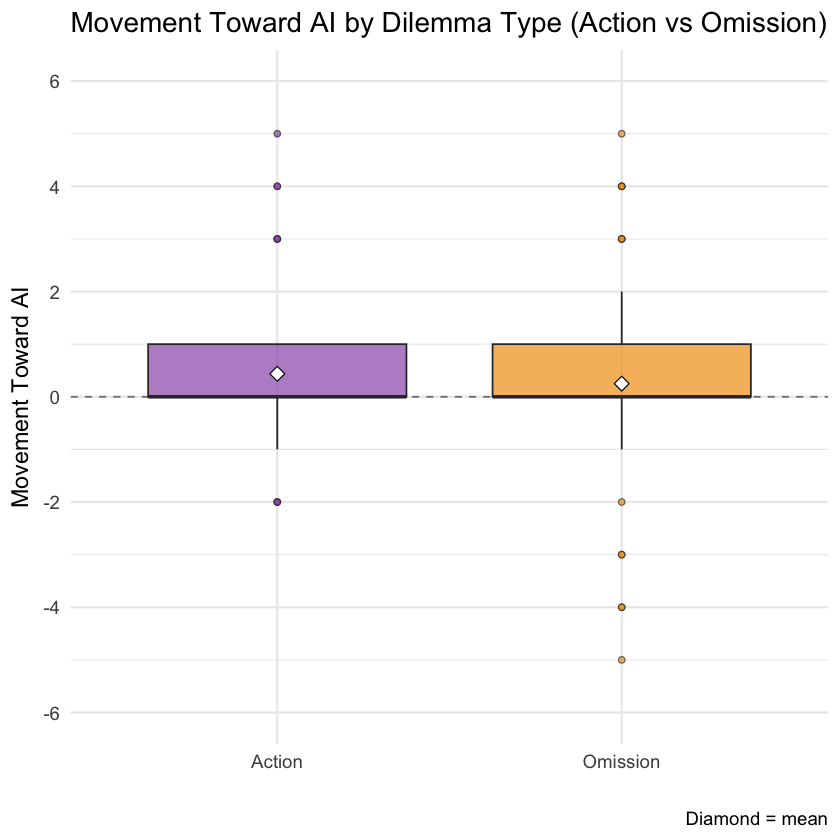

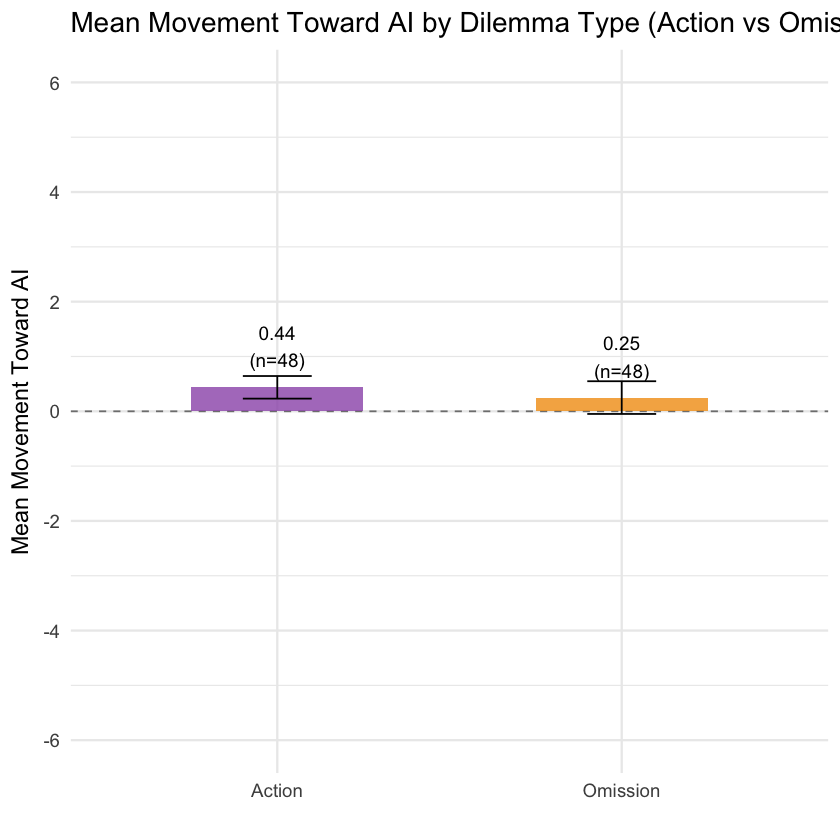

In [14]:
# Action vs Omission Analysis
data_with_type <- data_with_type %>%
mutate(
  dilemma_type = case_when(
    grepl("A_", dilemma) ~ "action",
    grepl("O_", dilemma) ~ "omission",
    TRUE ~ NA_character_
  )
)


action_omission_data <- data_with_type %>%
filter(!is.na(dilemma_type)) %>%
mutate(
dilemma_type = str_to_title(dilemma_type),
dilemma_type = factor(dilemma_type, levels = c("Action", "Omission")),
movement_toward_ai = case_when(
outcome == "Moved toward AI" ~ abs(rating_change),
outcome == "Backfired" ~ -abs(rating_change),
TRUE ~ 0
),
outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
)

# Summary stats
action_omission_stats <- action_omission_data %>%
group_by(dilemma_type) %>%
summarise(
n = n(),
mean_movement = mean(movement_toward_ai),
median_movement = median(movement_toward_ai),
sd_movement = sd(movement_toward_ai),
se_movement = sd_movement / sqrt(n),
.groups = "drop"
)
print(action_omission_stats)

# Wilcoxon test (2 groups)
action_data <- action_omission_data %>% filter(dilemma_type == "Action") %>% pull(movement_toward_ai)
omission_data <- action_omission_data %>% filter(dilemma_type == "Omission") %>% pull(movement_toward_ai)
wilcox_res <- wilcox.test(action_data, omission_data, exact = FALSE)
message(sprintf("\nAction vs Omission: W=%.0f, p=%.4f %s",
          wilcox_res$statistic, wilcox_res$p.value,
          ifelse(wilcox_res$p.value < 0.05, "*", "")))

# Binomial tests
for (type in c("Action", "Omission")) {
type_changed <- action_omission_data %>%
filter(dilemma_type == type, outcome %in% c("Moved toward AI", "Backfired"))
n_moved <- sum(type_changed$outcome == "Moved toward AI")
n_total <- nrow(type_changed)
if (n_total > 0) {
binom_res <- binom.test(n_moved, n_total, p = 0.5, alternative = "greater")
message(sprintf("%s: %d/%d moved toward AI (%.1f%%), binomial p=%.4f %s",
              type, n_moved, n_total, 100 * n_moved / n_total,
              binom_res$p.value, ifelse(binom_res$p.value < 0.05, "*", "")))
}
}

# 1. Stacked bar chart
action_omission_outcomes <- action_omission_data %>%
count(dilemma_type, outcome) %>%
group_by(dilemma_type) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

ggplot(action_omission_outcomes, aes(x = dilemma_type, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = sprintf("%.0f%%", pct)),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
scale_y_continuous(limits = c(0, 100), breaks = seq(0, 100, 20)) +
labs(title = "Outcome Distribution by Dilemma Type (Action vs Omission)",
     x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14)

# 2. Boxplot
ggplot(action_omission_data, aes(x = dilemma_type, y = movement_toward_ai, fill = dilemma_type)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(alpha = 0.7, outlier.shape = 21) +
stat_summary(fun = mean, geom = "point", shape = 23, size = 3, fill = "white") +
scale_fill_manual(values = c("Action" = "#9B59B6", "Omission" = "#F39C12")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI by Dilemma Type (Action vs Omission)",
 x = "", y = "Movement Toward AI", caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(action_omission_stats, aes(x = dilemma_type, y = mean_movement, fill = dilemma_type)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
      vjust = ifelse(action_omission_stats$mean_movement >= 0, -0.5, 1.5), size = 4) +
scale_fill_manual(values = c("Action" = "#9B59B6", "Omission" = "#F39C12")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI by Dilemma Type (Action vs Omission)",
 x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")


# A tibble: 19 × 6
   dilemma               n mean_movement median_movement sd_movement se_movement
   <chr>             <int>         <dbl>           <dbl>       <dbl>       <dbl>
 1 K_bgA_Abduction       2         2.5               2.5       3.54        2.5  
 2 K_bgO_Abduction       4         2.25              2.5       1.71        0.854
 3 K_bsO_Abduction       3         2                 2         2           1.15 
 4 K_bgA_Rawanda         5         1                 1         1.87        0.837
 5 K_bsA_Abduction       3         1                 0         1.73        1    
 6 K_bsO_Rawanda         5         1                 0         2.35        1.05 
 7 K_bsA_Vaccine         4         0.75              0         1.5         0.75 
 8 K_bsO_Vaccine         3         0.667             0         1.15        0.667
 9 K_bsA_Constructi…     3         0.333             0         0.577       0.333
10 G_PA_Terrorist_N…    13         0.308             0         1.49        0.414
11 G_IA_D


Overall: Kruskal-Wallis H=23.37, p=0.1769 



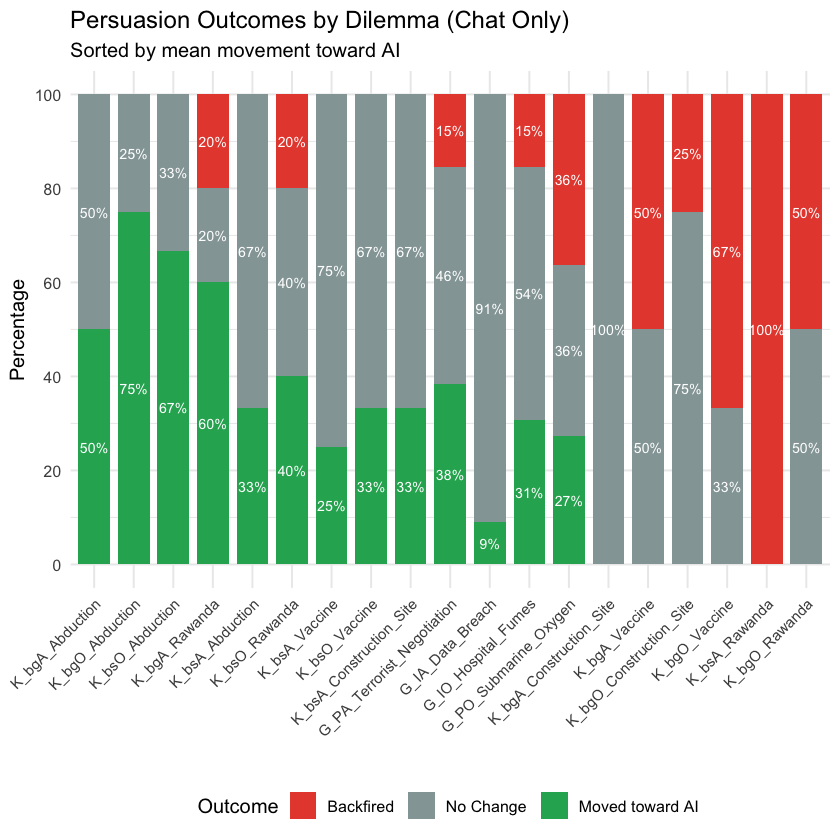

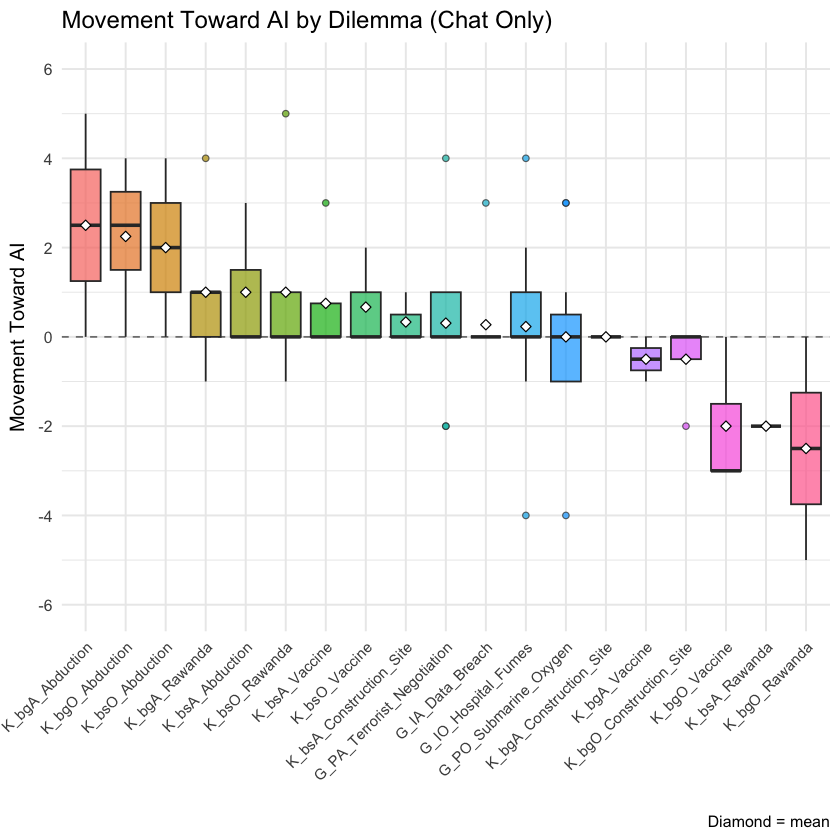

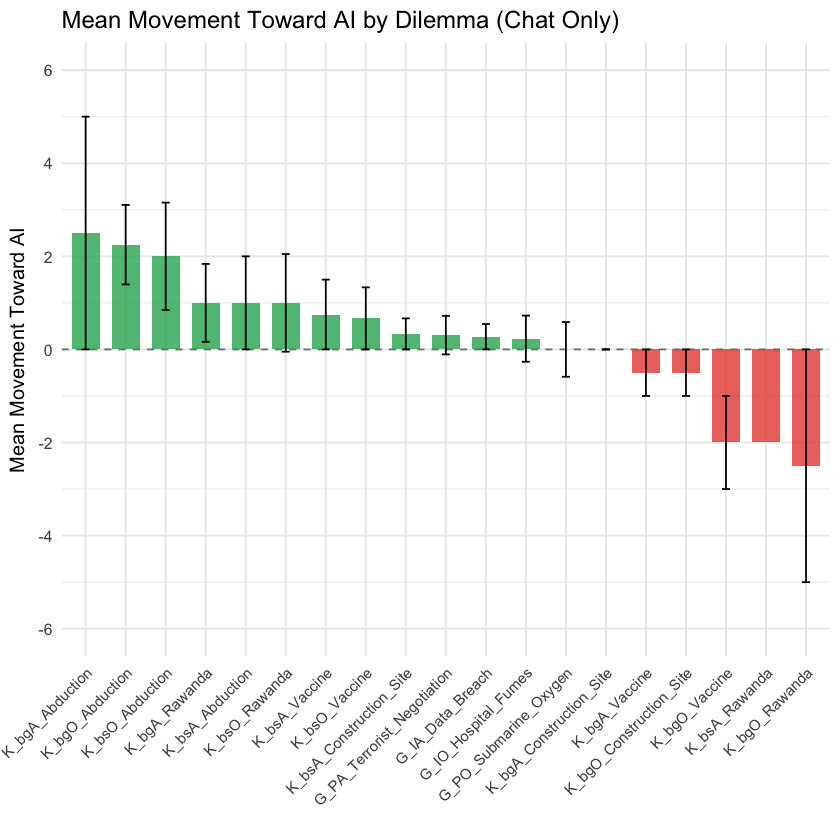

In [15]:
# Outcomes by dilemma: Only dilemmas that had chat conversations

dilemma_chat_data <- data_chat_analysis %>%
filter(had_chat == TRUE) %>%
mutate(
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
)

# Summary stats by dilemma
dilemma_stats <- dilemma_chat_data %>%
group_by(dilemma) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
) %>%
arrange(desc(mean_movement))

print(dilemma_stats)

# Create dilemma_order (sorted by mean movement)
dilemma_order <- dilemma_stats$dilemma

# Create dilemma_outcomes for stacked bar chart
dilemma_outcomes <- dilemma_chat_data %>%
count(dilemma, outcome) %>%
group_by(dilemma) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup() %>%
mutate(dilemma = factor(dilemma, levels = dilemma_order))

# Kruskal-Wallis test
kruskal_res <- kruskal.test(movement_toward_ai ~ dilemma, data = dilemma_chat_data)
message(sprintf("\nOverall: Kruskal-Wallis H=%.2f, p=%.4f %s",
              kruskal_res$statistic, kruskal_res$p.value,
              ifelse(kruskal_res$p.value < 0.05, "*", "")))

# 1. Stacked bar chart
ggplot(dilemma_outcomes, aes(x = dilemma, y = pct, fill = outcome)) +
geom_col(width = 0.8) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 3, color = "white") +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
scale_y_continuous(limits = c(0, 100), breaks = seq(0, 100, 20)) +
labs(title = "Persuasion Outcomes by Dilemma (Chat Only)",
     subtitle = "Sorted by mean movement toward AI",
     x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 12) +
theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 9),
      legend.position = "bottom")

# 2. Boxplot
dilemma_chat_data <- dilemma_chat_data %>%
mutate(dilemma = factor(dilemma, levels = dilemma_order))

ggplot(dilemma_chat_data, aes(x = dilemma, y = movement_toward_ai, fill = dilemma)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(alpha = 0.7, outlier.shape = 21) +
stat_summary(fun = mean, geom = "point", shape = 23, size = 2, fill = "white") +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI by Dilemma (Chat Only)",
     x = "", y = "Movement Toward AI", caption = "Diamond = mean") +
theme_minimal(base_size = 12) +
theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 9),
      legend.position = "none")

# 3. Mean bar chart
dilemma_stats <- dilemma_stats %>%
mutate(dilemma = factor(dilemma, levels = dilemma_order))

ggplot(dilemma_stats, aes(x = dilemma, y = mean_movement, fill = mean_movement > 0)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.7, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
scale_fill_manual(values = c("TRUE" = "#27AE60", "FALSE" = "#E74C3C")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI by Dilemma (Chat Only)",
     x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 12) +
theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 9),
      legend.position = "none")


Ethical framework alignment summary:



# A tibble: 2 × 8
  phase     n  mean    sd median pct_utilitarian pct_deontological pct_neutral
  <fct> <int> <dbl> <dbl>  <dbl>           <dbl>             <dbl>       <dbl>
1 Pre     192  3.43  1.96      3            32.3              54.7        13  
2 Post    192  3.49  2.13      3            33.3              51.6        15.1



Pre vs Post shift:

Paired Wilcoxon: V = 1768, p = 0.6550



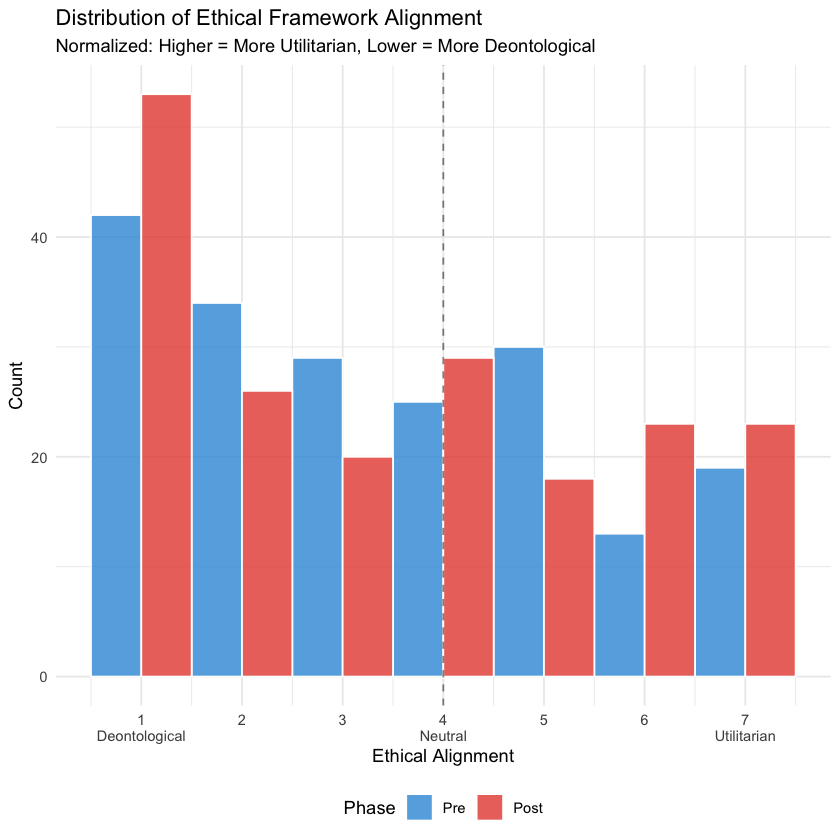

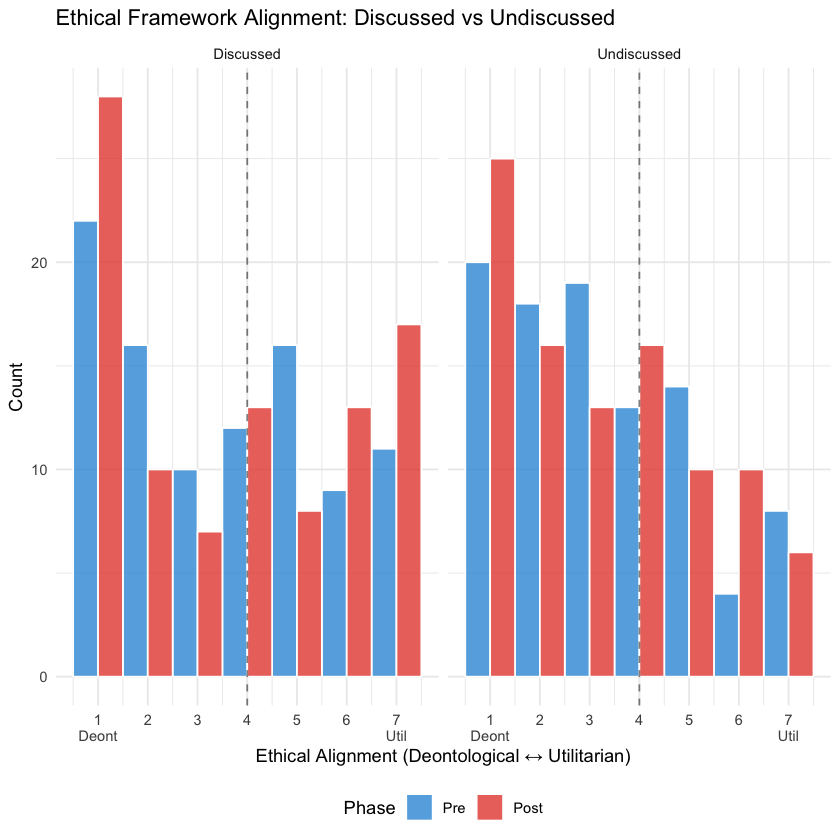

In [16]:
# Histogram of ethical framework alignment
  # Normalize ratings so higher = more utilitarian for all dilemmas

  rating_framework <- data_long %>%
    filter(!is.na(low_rating_framework)) %>%
    mutate(
      # Convert to utilitarian scale (higher = more utilitarian)
      utilitarian_pre = ifelse(low_rating_framework == "utilitarian",
                                8 - rating_pre,  # flip: low was utilitarian
                                rating_pre),      # keep: high is utilitarian
      utilitarian_post = ifelse(low_rating_framework == "utilitarian",
                                 8 - rating_post,
                                 rating_post)
    ) %>%
    dplyr::select(participant_id, dilemma, utilitarian_pre, utilitarian_post) %>%
    pivot_longer(cols = c(utilitarian_pre, utilitarian_post),
                 names_to = "phase", values_to = "utilitarian_score") %>%
    mutate(phase = ifelse(phase == "utilitarian_pre", "Pre", "Post"),
           phase = factor(phase, levels = c("Pre", "Post")))

  ggplot(rating_framework, aes(x = utilitarian_score, fill = phase)) +
    geom_histogram(binwidth = 1, position = "dodge", alpha = 0.8, color = "white") +
    scale_x_continuous(breaks = 1:7, labels = c("1\nDeontological", "2", "3", "4\nNeutral", "5", "6", "7\nUtilitarian")) +
    scale_fill_manual(values = c("Pre" = "#3498DB", "Post" = "#E74C3C")) +
    geom_vline(xintercept = 4, linetype = "dashed", alpha = 0.5) +
    labs(
      title = "Distribution of Ethical Framework Alignment",
      subtitle = "Normalized: Higher = More Utilitarian, Lower = More Deontological",
      x = "Ethical Alignment", y = "Count", fill = "Phase"
    ) +
    theme_minimal() +
    theme(legend.position = "bottom")

  # Summary stats
  message("Ethical framework alignment summary:")
  rating_framework %>%
    group_by(phase) %>%
    summarise(
      n = n(),
      mean = round(mean(utilitarian_score), 2),
      sd = round(sd(utilitarian_score), 2),
      median = median(utilitarian_score),
      pct_utilitarian = round(mean(utilitarian_score > 4) * 100, 1),
      pct_deontological = round(mean(utilitarian_score < 4) * 100, 1),
      pct_neutral = round(mean(utilitarian_score == 4) * 100, 1),
      .groups = "drop"
    ) %>%
    print()

  # Test for shift
  message("\nPre vs Post shift:")
  pre_scores <- rating_framework %>% filter(phase == "Pre") %>% pull(utilitarian_score)
  post_scores <- rating_framework %>% filter(phase == "Post") %>% pull(utilitarian_score)

  wilcox_res <- wilcox.test(pre_scores, post_scores, paired = TRUE, exact = FALSE)
  message(sprintf("Paired Wilcoxon: V = %.0f, p = %.4f", wilcox_res$statistic, wilcox_res$p.value))

  # Split by chat vs non-chat
  rating_framework_type <- data_long %>%
    filter(!is.na(low_rating_framework)) %>%
    mutate(
      dilemma_type = ifelse(had_chat, "Discussed", "Undiscussed"),
      utilitarian_pre = ifelse(low_rating_framework == "utilitarian", 8 - rating_pre, rating_pre),
      utilitarian_post = ifelse(low_rating_framework == "utilitarian", 8 - rating_post, rating_post)
    ) %>%
    dplyr::select(participant_id, dilemma, dilemma_type, utilitarian_pre, utilitarian_post) %>%
    pivot_longer(cols = c(utilitarian_pre, utilitarian_post),
                 names_to = "phase", values_to = "utilitarian_score") %>%
    mutate(phase = ifelse(phase == "utilitarian_pre", "Pre", "Post"),
           phase = factor(phase, levels = c("Pre", "Post")))

  ggplot(rating_framework_type, aes(x = utilitarian_score, fill = phase)) +
    geom_histogram(binwidth = 1, position = "dodge", alpha = 0.8, color = "white") +
    facet_wrap(~dilemma_type) +
    scale_x_continuous(breaks = 1:7, labels = c("1\nDeont", "2", "3", "4", "5", "6", "7\nUtil")) +
    scale_fill_manual(values = c("Pre" = "#3498DB", "Post" = "#E74C3C")) +
    geom_vline(xintercept = 4, linetype = "dashed", alpha = 0.5) +
    labs(
      title = "Ethical Framework Alignment: Discussed vs Undiscussed",
      x = "Ethical Alignment (Deontological ↔ Utilitarian)", y = "Count", fill = "Phase"
    ) +
    theme_minimal() +
    theme(legend.position = "bottom")


## Provider Effect (Claude vs Qwen)

In [ ]:
message("\n=== PROVIDER EFFECT: CLAUDE VS QWEN ===")

provider_data <- data_chat_analysis %>%
  mutate(
    provider = ifelse(llm_provider == "anthropic", "Claude", "Qwen"),
    provider = factor(provider, levels = c("Claude", "Qwen")),
    movement_toward_ai = case_when(
      outcome == "Moved toward AI" ~ abs(rating_change),
      outcome == "Backfired" ~ -abs(rating_change),
      TRUE ~ 0
    ),
    outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
  )

# Summary stats
provider_stats <- provider_data %>%
  group_by(provider) %>%
  summarise(
    n = n(),
    n_moved = sum(outcome == "Moved toward AI"),
    pct_moved = round(n_moved / n * 100, 1),
    mean_movement = mean(movement_toward_ai),
    sd_movement = sd(movement_toward_ai),
    se_movement = sd_movement / sqrt(n),
    .groups = "drop"
  )

message("Summary:")
print(provider_stats)

# Statistical tests
message("\n--- Movement toward AI (continuous) ---")
claude_movement <- provider_data %>% filter(provider == "Claude") %>% pull(movement_toward_ai)
qwen_movement <- provider_data %>% filter(provider == "Qwen") %>% pull(movement_toward_ai)

t_res <- t.test(claude_movement, qwen_movement)
message(sprintf("Claude vs Qwen: mean=%.2f vs %.2f", mean(claude_movement), mean(qwen_movement)))
message(sprintf("t-test: t=%.2f, df=%.1f, p=%.4f %s",
                t_res$statistic, t_res$parameter, t_res$p.value,
                ifelse(t_res$p.value < 0.05, "*", "")))

wilcox_res <- wilcox.test(claude_movement, qwen_movement, exact = FALSE)
message(sprintf("Wilcoxon: W=%.0f, p=%.4f %s",
                wilcox_res$statistic, wilcox_res$p.value,
                ifelse(wilcox_res$p.value < 0.05, "*", "")))

# Effect size (Cohen's d)
pooled_sd <- sqrt(((length(claude_movement)-1)*sd(claude_movement)^2 + 
                   (length(qwen_movement)-1)*sd(qwen_movement)^2) / 
                  (length(claude_movement) + length(qwen_movement) - 2))
cohens_d <- (mean(claude_movement) - mean(qwen_movement)) / pooled_sd
message(sprintf("Cohen's d = %.2f", cohens_d))

message("\n--- Likelihood of moving toward AI (binary) ---")
claude_n <- sum(provider_data$provider == "Claude")
claude_moved <- sum(provider_data$provider == "Claude" & provider_data$outcome == "Moved toward AI")
qwen_n <- sum(provider_data$provider == "Qwen")
qwen_moved <- sum(provider_data$provider == "Qwen" & provider_data$outcome == "Moved toward AI")

prop_res <- prop.test(c(claude_moved, qwen_moved), c(claude_n, qwen_n))
message(sprintf("Claude: %d/%d (%.1f%%) | Qwen: %d/%d (%.1f%%)",
                claude_moved, claude_n, claude_moved/claude_n*100,
                qwen_moved, qwen_n, qwen_moved/qwen_n*100))
message(sprintf("Proportion test: Chi-squared=%.2f, p=%.4f %s",
                prop_res$statistic, prop_res$p.value,
                ifelse(prop_res$p.value < 0.05, "*", "")))

# Outcome distribution
provider_outcomes <- provider_data %>%
  count(provider, outcome) %>%
  group_by(provider) %>%
  mutate(pct = n / sum(n) * 100) %>%
  ungroup()

# 1. Stacked bar chart
ggplot(provider_outcomes, aes(x = provider, y = pct, fill = outcome)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
            position = position_stack(vjust = 0.5), size = 4, color = "white") +
  scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
  labs(title = "Persuasion Outcomes by LLM Provider",
       x = "", y = "Percentage", fill = "Outcome") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

# 2. Boxplot
ggplot(provider_data, aes(x = provider, y = movement_toward_ai, fill = provider)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
  scale_fill_manual(values = c("Claude" = "#E67E22", "Qwen" = "#3498DB")) +
  scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
  labs(title = "Movement Toward AI by LLM Provider",
       x = "", y = "Movement Toward AI", caption = "Diamond = mean") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

# 3. Mean bar chart
ggplot(provider_stats, aes(x = provider, y = mean_movement, fill = provider)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_col(width = 0.5, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
  geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
            vjust = ifelse(provider_stats$mean_movement >= 0, -0.5, 1.5), size = 4) +
  scale_fill_manual(values = c("Claude" = "#E67E22", "Qwen" = "#3498DB")) +
  scale_y_continuous(limits = c(-2, 2), breaks = seq(-2, 2, 1)) +
  labs(title = "Mean Movement Toward AI by LLM Provider",
       x = "", y = "Mean Movement Toward AI") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

In [ ]:
message("\n=== ENGAGEMENT METRICS: CHAT TURNS ===")

engagement_data <- data_chat_analysis %>%
  mutate(
    movement_toward_ai = case_when(
      outcome == "Moved toward AI" ~ abs(rating_change),
      outcome == "Backfired" ~ -abs(rating_change),
      TRUE ~ 0
    ),
    moved_binary = as.integer(outcome == "Moved toward AI"),
    outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
  )

# Summary stats
message("Chat turns summary:")
engagement_data %>%
  summarise(
    n = n(),
    mean_turns = mean(chat_turns, na.rm = TRUE),
    sd_turns = sd(chat_turns, na.rm = TRUE),
    min_turns = min(chat_turns, na.rm = TRUE),
    max_turns = max(chat_turns, na.rm = TRUE),
    median_turns = median(chat_turns, na.rm = TRUE)
  ) %>%
  print()

# Chat turns by outcome
message("\nChat turns by outcome:")
engagement_data %>%
  group_by(outcome) %>%
  summarise(
    n = n(),
    mean_turns = mean(chat_turns, na.rm = TRUE),
    sd_turns = sd(chat_turns, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  print()

# Correlation: chat turns vs movement
message("\n--- Correlation: Chat turns vs Movement ---")
cor_res <- cor.test(engagement_data$chat_turns, engagement_data$movement_toward_ai)
message(sprintf("Pearson r = %.2f, p = %.4f %s",
                cor_res$estimate, cor_res$p.value,
                ifelse(cor_res$p.value < 0.05, "*", "")))

spearman_res <- cor.test(engagement_data$chat_turns, engagement_data$movement_toward_ai, method = "spearman")
message(sprintf("Spearman rho = %.2f, p = %.4f %s",
                spearman_res$estimate, spearman_res$p.value,
                ifelse(spearman_res$p.value < 0.05, "*", "")))

# Compare chat turns: moved vs not moved
message("\n--- Chat turns: Moved vs Not moved ---")
moved_turns <- engagement_data %>% filter(outcome == "Moved toward AI") %>% pull(chat_turns)
not_moved_turns <- engagement_data %>% filter(outcome != "Moved toward AI") %>% pull(chat_turns)

t_res <- t.test(moved_turns, not_moved_turns)
message(sprintf("Moved: M=%.1f (SD=%.1f) | Not moved: M=%.1f (SD=%.1f)",
                mean(moved_turns), sd(moved_turns), 
                mean(not_moved_turns), sd(not_moved_turns)))
message(sprintf("t-test: t=%.2f, p=%.4f %s",
                t_res$statistic, t_res$p.value,
                ifelse(t_res$p.value < 0.05, "*", "")))

# Median split analysis
median_turns <- median(engagement_data$chat_turns, na.rm = TRUE)
engagement_data <- engagement_data %>%
  mutate(
    engagement_group = ifelse(chat_turns <= median_turns, "Short", "Long"),
    engagement_group = factor(engagement_group, levels = c("Short", "Long"))
  )

message(sprintf("\nMedian split (median = %.0f turns):", median_turns))
engagement_data %>%
  group_by(engagement_group) %>%
  summarise(
    n = n(),
    n_moved = sum(outcome == "Moved toward AI"),
    pct_moved = round(n_moved / n * 100, 1),
    mean_movement = mean(movement_toward_ai),
    .groups = "drop"
  ) %>%
  print()

# 1. Scatter plot with trend line
ggplot(engagement_data, aes(x = chat_turns, y = movement_toward_ai)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_jitter(aes(color = outcome), width = 0.3, alpha = 0.7, size = 3) +
  geom_smooth(method = "lm", se = TRUE, color = "black", linetype = "dashed") +
  scale_color_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
  scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
  labs(title = "Chat Turns vs Movement Toward AI",
       subtitle = sprintf("r = %.2f, p = %.3f", cor_res$estimate, cor_res$p.value),
       x = "Number of Chat Turns", y = "Movement Toward AI", color = "Outcome") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom")

# 2. Boxplot by outcome
ggplot(engagement_data, aes(x = outcome, y = chat_turns, fill = outcome)) +
  geom_boxplot(width = 0.5, alpha = 0.7) +
  geom_jitter(width = 0.1, alpha = 0.5, size = 2) +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
  scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
  labs(title = "Chat Turns by Persuasion Outcome",
       x = "", y = "Number of Chat Turns", caption = "Diamond = mean") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

# 3. Histogram of chat turns
ggplot(engagement_data, aes(x = chat_turns, fill = outcome)) +
  geom_histogram(binwidth = 2, position = "stack", alpha = 0.8, color = "white") +
  scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
  geom_vline(xintercept = median_turns, linetype = "dashed", color = "black") +
  annotate("text", x = median_turns + 1, y = Inf, label = sprintf("Median = %.0f", median_turns), 
           vjust = 2, hjust = 0, size = 4) +
  labs(title = "Distribution of Chat Turns by Outcome",
       x = "Number of Chat Turns", y = "Count", fill = "Outcome") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom")

## Effect Sizes for Significant Findings

In [ ]:
message("\n=== EFFECT SIZES FOR SIGNIFICANT FINDINGS ===")

# Helper function for Cohen's d
cohens_d <- function(x, y) {
  nx <- length(x)
  ny <- length(y)
  pooled_sd <- sqrt(((nx - 1) * sd(x)^2 + (ny - 1) * sd(y)^2) / (nx + ny - 2))
  d <- (mean(x) - mean(y)) / pooled_sd
  return(d)
}

# Helper function for interpretation
interpret_d <- function(d) {
  abs_d <- abs(d)
  if (abs_d < 0.2) return("negligible")
  if (abs_d < 0.5) return("small")
  if (abs_d < 0.8) return("medium")
  return("large")
}

# Prepare data
effect_data <- data_chat_analysis %>%
  mutate(
    movement_toward_ai = case_when(
      outcome == "Moved toward AI" ~ abs(rating_change),
      outcome == "Backfired" ~ -abs(rating_change),
      TRUE ~ 0
    ),
    is_opposing = stance_mode == "opposite",
    provider = ifelse(llm_provider == "anthropic", "Claude", "Qwen")
  )

# 1. H6: Opposing vs Reinforcing stance
message("\n--- H6: Opposing vs Reinforcing Stance ---")
opposing_movement <- effect_data %>% filter(is_opposing == TRUE) %>% pull(movement_toward_ai)
reinforcing_movement <- effect_data %>% filter(is_opposing == FALSE) %>% pull(movement_toward_ai)

d_h6 <- cohens_d(opposing_movement, reinforcing_movement)
message(sprintf("Opposing: M = %.2f (SD = %.2f), n = %d",
                mean(opposing_movement), sd(opposing_movement), length(opposing_movement)))
message(sprintf("Reinforcing: M = %.2f (SD = %.2f), n = %d",
                mean(reinforcing_movement), sd(reinforcing_movement), length(reinforcing_movement)))
message(sprintf("Cohen's d = %.2f (%s effect)", d_h6, interpret_d(d_h6)))

# 2. Provider: Claude vs Qwen
message("\n--- Provider: Claude vs Qwen ---")
claude_movement <- effect_data %>% filter(provider == "Claude") %>% pull(movement_toward_ai)
qwen_movement <- effect_data %>% filter(provider == "Qwen") %>% pull(movement_toward_ai)

d_provider <- cohens_d(claude_movement, qwen_movement)
message(sprintf("Claude: M = %.2f (SD = %.2f), n = %d",
                mean(claude_movement), sd(claude_movement), length(claude_movement)))
message(sprintf("Qwen: M = %.2f (SD = %.2f), n = %d",
                mean(qwen_movement), sd(qwen_movement), length(qwen_movement)))
message(sprintf("Cohen's d = %.2f (%s effect)", d_provider, interpret_d(d_provider)))

# 3. Discussed vs Undiscussed (magnitude of change)
message("\n--- H5: Discussed vs Undiscussed (|change|) ---")
discussed_change <- data_long %>% filter(had_chat == TRUE) %>% pull(rating_change) %>% abs()
undiscussed_change <- data_long %>% filter(had_chat == FALSE) %>% pull(rating_change) %>% abs()

d_discussed <- cohens_d(discussed_change, undiscussed_change)
message(sprintf("Discussed: M = %.2f (SD = %.2f), n = %d",
                mean(discussed_change), sd(discussed_change), length(discussed_change)))
message(sprintf("Undiscussed: M = %.2f (SD = %.2f), n = %d",
                mean(undiscussed_change), sd(undiscussed_change), length(undiscussed_change)))
message(sprintf("Cohen's d = %.2f (%s effect)", d_discussed, interpret_d(d_discussed)))

# Summary table
message("\n=== EFFECT SIZE SUMMARY ===")
effect_summary <- data.frame(
  Comparison = c("H6: Opposing vs Reinforcing", "Provider: Claude vs Qwen", "H5: Discussed vs Undiscussed"),
  Group1_M = c(mean(opposing_movement), mean(claude_movement), mean(discussed_change)),
  Group1_SD = c(sd(opposing_movement), sd(claude_movement), sd(discussed_change)),
  Group2_M = c(mean(reinforcing_movement), mean(qwen_movement), mean(undiscussed_change)),
  Group2_SD = c(sd(reinforcing_movement), sd(qwen_movement), sd(undiscussed_change)),
  Cohens_d = c(d_h6, d_provider, d_discussed),
  Interpretation = c(interpret_d(d_h6), interpret_d(d_provider), interpret_d(d_discussed))
)

print(effect_summary)

# Visualization
effect_plot_data <- data.frame(
  Comparison = c("H6: Opposing\nvs Reinforcing", "Provider:\nClaude vs Qwen", "H5: Discussed\nvs Undiscussed"),
  d = c(d_h6, d_provider, d_discussed),
  significant = c(TRUE, TRUE, TRUE)  # Update based on actual significance
)

ggplot(effect_plot_data, aes(x = reorder(Comparison, abs(d)), y = d, fill = d > 0)) +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_hline(yintercept = c(-0.8, -0.5, -0.2, 0, 0.2, 0.5, 0.8), 
             linetype = "dashed", color = "gray70", alpha = 0.5) +
  geom_text(aes(label = sprintf("d = %.2f", d)), 
            hjust = ifelse(effect_plot_data$d > 0, -0.1, 1.1), size = 4) +
  scale_fill_manual(values = c("FALSE" = "#E74C3C", "TRUE" = "#27AE60"), guide = "none") +
  coord_flip() +
  scale_y_continuous(limits = c(-1, 1.5), breaks = seq(-1, 1.5, 0.5)) +
  labs(title = "Effect Sizes (Cohen's d) for Key Comparisons",
       subtitle = "Dashed lines at d = 0.2 (small), 0.5 (medium), 0.8 (large)",
       x = "", y = "Cohen's d") +
  theme_minimal(base_size = 14) +
  annotate("text", x = 0.5, y = 0.2, label = "small", size = 3, color = "gray50") +
  annotate("text", x = 0.5, y = 0.5, label = "medium", size = 3, color = "gray50") +
  annotate("text", x = 0.5, y = 0.8, label = "large", size = 3, color = "gray50")